In [998]:
"""
SED_plotting was getting too full so I added some plots here. 
Using the results from ProSpect, filtered for which model best fits each galaxy,
I plot time evolution (with redshift) for SED properties and morphology properties.
Plotting morphological results from all_morphology tables is executed here also.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
from IPython.display import display, Math
import math
import emcee
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator
import os
import re

SERSIC_FILTERS = ["F444W", "F356W", "F277W"]

FIG_DIR = "/nvme/scratch/work/alberttg/Summer_project/Plots"

In [999]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [1000]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [1001]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params,
                                  x_obs=None, x_err_low=None, x_err_high=None,
                                  gradient=None):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties,
    optionally including x uncertainties projected onto y via the model gradient.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    y_model : array_like
        Model predictions.
    n_params : int
        Number of fitted parameters.
    x_obs : array_like, optional
        Observed x values. Required if x_err_low/x_err_high are given.
    x_err_low : array_like, optional
        Lower (negative) uncertainties on x. If None, treated as zero.
    x_err_high : array_like, optional
        Upper (positive) uncertainties on x. If None, treated as zero.
    gradient : float, optional
        Local gradient of the model (dy/dx), used to project x uncertainty
        onto y. Required if x uncertainties are non-zero.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err_low = np.asarray(y_err_low, dtype=float)
    y_err_high = np.asarray(y_err_high, dtype=float)

    # Use the appropriate uncertainty depending on which side of the data
    sigma_y = np.where(y_model > y_obs, y_err_high, y_err_low)

    # Handle x uncertainties, if provided
    if x_err_low is None:
        x_err_low = np.zeros_like(y_obs)
    else:
        x_err_low = np.asarray(x_err_low, dtype=float)

    if x_err_high is None:
        x_err_high = np.zeros_like(y_obs)
    else:
        x_err_high = np.asarray(x_err_high, dtype=float)

    # If x errors are all zero, skip the x-error projection entirely —
    # this avoids requiring x_obs/gradient when there's nothing to project
    if np.all(x_err_low == 0) and np.all(x_err_high == 0):
        sigma = sigma_y
    else:
        if x_obs is None or gradient is None:
            raise ValueError("x_obs and gradient must be provided when x uncertainties are non-zero.")

        x_obs = np.asarray(x_obs, dtype=float)
        sigma_x = np.where(y_model > y_obs, x_err_high, x_err_low)

        # project x uncertainty onto y using the model gradient, combine in quadrature
        sigma = np.sqrt(sigma_y**2 + (gradient * sigma_x)**2)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [1002]:
def calculate_nmad(y, y_err_high, y_err_low, y_model, x_err_high, x_err_low, gradient, int_scatter):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    y_sigma = np.where(
        residuals > 0,
        y_err_low,   # data lie above model
        y_err_high   # data lie below model
    )

    if x_err_high is None or x_err_low is None or gradient is None:
        x_err_high = np.zeros_like(y)
        x_err_low = np.zeros_like(y)
        gradient = 0.0

    if int_scatter is None:
        int_scatter = 0.0
    
    if gradient >= 0:
        x_sig = np.where(residuals >= 0, x_err_high, x_err_low)
        # If residual is positive and slope is positive, use upper x error
    else:
        x_sig = np.where(residuals >= 0, x_err_low, x_err_high)
        # if residual is negative and slope is negative, use upper x error.
        # if residual is positive and slope is negative, use lower x error.

    total_sigma = np.sqrt(y_sigma**2 + (gradient * x_sig)**2 + int_scatter**2)

    normalised_residuals = residuals / total_sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [1003]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [1004]:
def format_value_uncertainty(value, upper_err, lower_err):
    """
    Format a value with asymmetric uncertainties using standard
    significant-figure rules (PDG rounding: 1 sig fig, or 2 if the
    leading digit is 1 or 2).

    Parameters
    ----------
    value : float
        Central value.
    upper_err : float
        +1 sigma uncertainty.
    lower_err : float
        -1 sigma uncertainty.

    Returns
    -------
    value_str, upper_str, lower_str : str
        Formatted value and uncertainties, all rounded to a consistent
        number of decimal places.
    """

    if upper_err == 0 and lower_err == 0:
        return f"{value:.3f}", "0", "0"

    def get_decimals(err):
        if err == 0:
            return 0
        exponent = math.floor(math.log10(abs(err)))
        first_digit = int(abs(err) / 10**exponent)
        sig_figs = 2 if first_digit in [1, 2] else 1
        return -(exponent - (sig_figs - 1))

    # decide precision using whichever error needs more decimal places,
    # so neither error gets rounded away to zero
    decimals = max(get_decimals(upper_err), get_decimals(lower_err))

    value_rounded = round(value, decimals)
    upper_rounded = round(upper_err, decimals)
    lower_rounded = round(lower_err, decimals)

    fmt = f"{{:.{max(decimals, 0)}f}}"

    return fmt.format(value_rounded), fmt.format(upper_rounded), fmt.format(lower_rounded)

In [1005]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl

In [1006]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [1007]:
def _parse_err(err, n):
    """
    Normalize an error specification into (err_lo, err_hi) arrays of length n.

    Accepted forms for `err`:
      - None                            -> zeros (no error)
      - scalar or 1D array of length n  -> symmetric error (same as before)
      - [err_high, err_low]             -> asymmetric error; each of
        err_high/err_low can be a scalar (applied to all points) or a
        length-n array (per-point)

    Returned lo/hi are positive distances from the central value
    (lower bound = value - lo, upper bound = value + hi).
    """
    if err is None:
        return np.zeros(n), np.zeros(n)

    # Asymmetric: [err_high, err_low]
    if isinstance(err, (list, tuple)) and len(err) == 2:
        hi = np.asarray(err[0], dtype=float)
        lo = np.asarray(err[1], dtype=float)
        if hi.ndim == 0:
            hi = np.full(n, float(hi))
        if lo.ndim == 0:
            lo = np.full(n, float(lo))
        return lo.copy(), hi.copy()

    # Symmetric: scalar or array, same as before
    arr = np.asarray(err, dtype=float)
    if arr.ndim == 0:
        arr = np.full(n, float(arr))
    return arr.copy(), arr.copy()


def fit_linear_mcmc(x_in, y_in, x_err=None, y_err=None, x_pivot=None,
                     n_walkers=50, n_steps=10000, plot=False, save_path=None):
    """
    Bayesian linear fit y = m*(x - x_pivot) + c with intrinsic scatter,
    supporting asymmetric measurement errors in both x and y.

    x_err / y_err each accept:
      - None, a scalar, or a 1D array of length N (symmetric errors, same
        as before), OR
      - [err_high, err_low] for asymmetric errors, where each of
        err_high/err_low is a scalar (applied to every point) or a
        length-N array (per-point).

    Asymmetric-error handling
    --------------------------
    Each data point's error distribution is modeled as a split-normal
    (two-piece Gaussian): width `sigma_lo` below the measured value and
    `sigma_hi` above it. At every MCMC step, for each point we compare the
    model prediction to the data (delta = model - data) and pick the
    error side consistent with that comparison:
        delta >= 0  ->  use the "hi" error (model sits above the data)
        delta <  0  ->  use the "lo" error (model sits below the data)
    This is applied to both the y errors and the x errors (the latter
    projected into y-space via the slope, m^2 * xerr^2, as in the
    symmetric case). This is the standard practical approximation for
    asymmetric errors in a likelihood — it is exact only when the true
    error distribution really is split-normal, but works well in general
    and reduces to the ordinary symmetric-error likelihood when lo == hi.
    The intrinsic scatter term sigma_int is kept symmetric.
    """
    # --- Step 1: Data Cleaning & Pivot Handling ---
    x = np.asarray(x_in, dtype=float)
    y = np.asarray(y_in, dtype=float)
    n = len(x)

    xe_lo, xe_hi = _parse_err(x_err, n)
    ye_lo, ye_hi = _parse_err(y_err, n)

    xp = 0.0 if x_pivot is None else x_pivot

    mask = (
        np.isfinite(x) & np.isfinite(y)
        & np.isfinite(xe_lo) & np.isfinite(xe_hi)
        & np.isfinite(ye_lo) & np.isfinite(ye_hi)
    )

    # Guard against zero/negative error entries (keeps likelihood well-defined)
    xe_lo = np.where(xe_lo <= 0, 1e-10, xe_lo)
    xe_hi = np.where(xe_hi <= 0, 1e-10, xe_hi)
    ye_lo = np.where(ye_lo <= 0, 1e-10, ye_lo)
    ye_hi = np.where(ye_hi <= 0, 1e-10, ye_hi)

    x, y = x[mask], y[mask]
    xe_lo, xe_hi = xe_lo[mask], xe_hi[mask]
    ye_lo, ye_hi = ye_lo[mask], ye_hi[mask]

    if len(x) < 2:
        raise ValueError("Not enough finite data points.")

    # --- Step 2: Robust Initial Guess ---
    try:
        guess_m, guess_c = np.polyfit(x - xp, y, 1)
    except np.linalg.LinAlgError:
        guess_m, guess_c = 0.0, np.mean(y)

    guess_sigma = np.std(y - (guess_m * (x - xp) + guess_c))

    # --- Step 3: MCMC Functions (3 parameters: m, c, sigma_int) ---
    def log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        m, c, sigma_int = theta
        if sigma_int <= 0:
            return -np.inf

        model = m * (x - xp) + c
        delta = model - y  # positive => model above data

        y_sig = np.where(delta >= 0, yerr_hi, yerr_lo)
        x_sig = np.where(delta >= 0, xerr_hi, xerr_lo)

        sigma2 = y_sig**2 + (m**2 * x_sig**2) + sigma_int**2
        return -0.5 * np.sum(delta**2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta):
        m, c, sigma_int = theta
        if -20.0 < m < 20.0 and -20.0 < c < 20.0 and 0.0 < sigma_int < 10.0:
            return 0.0
        return -np.inf

    def log_probability(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp)
        return lp + ll if np.isfinite(ll) else -np.inf

    # --- Step 4: Run MCMC ---
    ndim = 3
    initial = np.array([guess_m, guess_c, guess_sigma if guess_sigma > 0 else 0.1])
    pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability,
        args=(x, y, xe_lo, xe_hi, ye_lo, ye_hi, xp)
    )
    sampler.run_mcmc(pos, n_steps, progress=True)

    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    x_range = np.linspace(x.min(), x.max(), 100)
    m_samples = flat_samples[:, 0]
    c_samples = flat_samples[:, 1]
    sig_samples = flat_samples[:, 2]

    models = m_samples[:, np.newaxis] * (x_range - xp) + c_samples[:, np.newaxis]

    m_med, c_med, sig_med = np.median(flat_samples, axis=0)
    lower_bound = np.percentile(models, 16, axis=0)
    upper_bound = np.percentile(models, 84, axis=0)

    # --- Step 5: Visualization ---
    if plot:
        plt.figure(figsize=(8, 6))
        print(f"Median slope: {m_med:.3f}, Intercept: {c_med:.3f}, Intrinsic Scatter: {sig_med:.3f}")

        # matplotlib expects asymmetric errors as [lower_distances, upper_distances]
        plt.errorbar(
            x, y,
            xerr=[xe_lo, xe_hi], yerr=[ye_lo, ye_hi],
            fmt=".k", alpha=0.4, label="Data", zorder=1
        )
        plt.fill_between(x_range, lower_bound, upper_bound, color="royalblue", alpha=0.3, label=r"1$\sigma$ Confidence")
        plt.plot(x_range, m_med * (x_range - xp) + c_med, color="darkblue", lw=2, label="Median Fit")
        plt.legend()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

        labels = ["Slope $m$", f"Intercept $c$ (at $x={xp}$)", r"$\sigma_{int}$"]
        corner.corner(flat_samples, labels=labels, truths=[m_med, c_med, sig_med], show_titles=True)
        plt.show()

    results = {
        "m_median": m_med,
        "c_median": c_med,
        "sig_int_median": sig_med,
        "m_16": np.percentile(flat_samples[:, 0], 16),
        "m_84": np.percentile(flat_samples[:, 0], 84),
        "c_16": np.percentile(flat_samples[:, 1], 16),
        "c_84": np.percentile(flat_samples[:, 1], 84),
        "sig_int_16": np.percentile(flat_samples[:, 2], 16),
        "sig_int_84": np.percentile(flat_samples[:, 2], 84),
        "x_pivot": xp,
    }

    return results

In [1008]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_upper_err : float
        1-sigma upper uncertainty on slope.
    gradient_lower_err : float
        1-sigma lower uncertainty on slope.
    intercept_upper_err : float
        1-sigma upper uncertainty on intercept.
    intercept_lower_err : float
        1-sigma lower uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    line_kwargs = {} if line_kwargs is None else line_kwargs.copy()
    line_kwargs.setdefault("color", colour)
    line_kwargs.setdefault("lw", 3)
    line_kwargs.setdefault("linestyle", "--")

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    xmin, xmax = np.min(x), np.max(x)
    pad = 0.01 * (xmax - xmin)
    x_plot = np.linspace(xmin - pad, xmax + pad, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_upper_err) * x_plot
               + (intercept + intercept_upper_err))

    y_lower = ((gradient - gradient_lower_err) * x_plot
               + (intercept - intercept_lower_err))

    ax.plot(x_plot, y, label=label,zorder=zorder, **line_kwargs)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, zorder=zorder, **band_kwargs)
    

In [1009]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    is_upper_limit,
    up_lim_direction,
    plot_points,
):
    """
    Fit a straight line to data with asymmetric errors and plot the results.
    Parameters
    ----------
    x : array-like
        x-data.
    x_upper_err : array-like
        Upper uncertainties on x.
    x_lower_err : array-like
        Lower uncertainties on x.
    y : array-like
        y-data.
    y_upper_err : array-like
        Upper uncertainties on y.
    y_lower_err : array-like
        Lower uncertainties on y.
    plot_colours : array-like or str
        Colours for each data point.
    ax : matplotlib.axes.Axes
        Axis to plot on.
    is_upper_limit : array of bool
        Indicates whether each data point is an upper limit.
    up_lim_direction : array-like or str
        Direction of the upper limits.
    plot_points : bool
        Whether to plot the data points or not.
    """

    if x_lower_err is None or x_upper_err is None:
        x_lower_err = np.zeros_like(x)
        x_upper_err = np.zeros_like(x)

    # Treat "no upper limits" (None / False / not supplied) as an all-False
    # mask, and switch off arrow-drawing entirely if no direction is given.
    if is_upper_limit is None or is_upper_limit is False:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    else:
        is_upper_limit = np.asarray(is_upper_limit, dtype=bool)

    if up_lim_direction is None:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    
    results = fit_linear_mcmc(x_in=x, y_in=y, 
                              x_err=[x_upper_err, x_lower_err], 
                              y_err=[y_upper_err, y_lower_err], 
                              x_pivot=None, n_walkers=50, n_steps=2000, plot=False, save_path=None)

    gradient = results["m_median"]
    gradient_upper_err = results["m_84"] - results["m_median"]
    gradient_lower_err = results["m_median"] - results["m_16"]
    intercept = results["c_median"]
    intercept_upper_err = results["c_84"] - results["c_median"]
    intercept_lower_err = results["c_median"] - results["c_16"]
    int_scatter_med = results["sig_int_median"]


    x_dummy_data = np.linspace(0.95 * np.min(x), 1.05 * np.max(x), 500)

    y_model = straight_line(x, gradient, intercept)

    weighted_red_chi = weighted_reduced_chi_squared(y_obs=y, y_err_low=y_lower_err, y_err_high=y_upper_err, y_model=y_model, n_params=2,
                                  x_obs=x, x_err_low=x_lower_err, x_err_high=x_upper_err,
                                  gradient=gradient)

    nmad = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept), x_upper_err, x_lower_err, gradient, int_scatter_med)

    # Normal points
    normal_marker_size = 40
    normal_marker_edgecolor = '0.3'
    normal_marker_linewidth = 0.7
    normal_marker_alpha = 0.4

    # Upper-limit points:
    limit_marker_size = 70
    limit_marker_edgecolor = '0.1'
    limit_linewidth = 2.0
    limit_alpha = 0.9

    if ax is not None:
        
        if plot_points==True:

            if isinstance(plot_colours, str):
                plot_colours = [plot_colours] * len(x)

            stellar_limit_label_added = False

            for xi, yi, xeu, xel, yeu, yel, colour, upper_limit in zip(x, y, x_upper_err, x_lower_err, y_upper_err, y_lower_err, plot_colours, is_upper_limit):

                if upper_limit:
                    marker_size = limit_marker_size
                    linewidth = limit_linewidth
                    edgecolor = limit_marker_edgecolor
                    alpha = limit_alpha

                    if not stellar_limit_label_added:
                        # Only label the first point with a stellar mass limit marker to avoid duplicate legend entries
                        label = "Stellar mass limit"
                        stellar_limit_label_added = True
                    else:
                        label = None
                else:
                    marker_size = normal_marker_size
                    linewidth = normal_marker_linewidth
                    edgecolor = normal_marker_edgecolor
                    alpha = normal_marker_alpha
                    label = None

                ax.scatter(
                        xi,
                        yi,
                        s=marker_size,
                        color=colour,
                        edgecolor=edgecolor,
                        linewidths=linewidth,
                        marker='o',
                        zorder=3
                    )

                ax.tick_params(
                    axis="both",
                    which="major",
                    labelsize=14,
                    length=8,
                    width=1.5,
                    direction="in",
                    top=True,
                    right=True
                )

                ax.xaxis.set_minor_locator(AutoMinorLocator(5))
                ax.yaxis.set_minor_locator(AutoMinorLocator(5))

                ax.tick_params(
                    axis="both",
                    which="minor",
                    length=4,
                    width=1,
                    direction="in",
                    top=True,
                    right=True
                )

                # Which direction should the limit arrow point?
                xuplims = False
                xlolims = False
                uplims = False
                lolims = False

                if upper_limit and up_lim_direction is not None:
                    if up_lim_direction == "left":
                        xuplims = True
                    elif up_lim_direction == "right":
                        xlolims = True
                    elif up_lim_direction == "up":
                        uplims = True
                    elif up_lim_direction == "down":
                        lolims = True
                    else:
                        raise ValueError("up_lim_direction must be one of 'left', 'right', 'up', or 'down'.")
                

                ax.errorbar(
                    xi,
                    yi,
                    xerr=[[xel], [xeu]],
                    yerr=[[yel], [yeu]],
                    color=colour,
                    fmt='none',
                    alpha=alpha,
                    lw=linewidth,
                    xuplims=xuplims,
                    xlolims=xlolims,
                    uplims=uplims,
                    lolims=lolims,
                    label=label,
                    zorder=2
                )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Intrinsic scatter from fit = {int_scatter_med:.3f}")
        print(f"NMAD of normalised residuals = {nmad:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi


In [1010]:
def add_marginal_hists(ax, x, y, bins=30, size="15%", pad=0.1, color="gray"):
    """
    Add marginal histograms of x and y on top of and to the right of ax,
    without disturbing ax's existing content (scatter, legend, etc.).

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to attach histograms to.
    x, y : array-like
        Data for the x and y histograms.
    bins : int
        Number of histogram bins.
    size : str
        Size of the marginal axes relative to ax (e.g. "15%").
    pad : float
        Padding between ax and the marginal axes.
    color : str
        Histogram color.

    Returns
    -------
    ax_histx, ax_histy : the two new marginal axes
    """
    divider = make_axes_locatable(ax)

    # Top histogram (x-axis distribution)
    ax_histx = divider.append_axes("top", size=size, pad=pad, sharex=ax)
    ax_histx.hist(x, bins=bins, color=color, edgecolor='0.2', linewidth=0.5)
    ax_histx.tick_params(axis="x", labelbottom=False)  # hide x labels (shared with ax)
    ax_histx.set_yticks([])
    for spine in ["top", "right", "left"]:
        ax_histx.spines[spine].set_visible(False)

    # Right histogram (y-axis distribution)
    ax_histy = divider.append_axes("right", size=size, pad=pad, sharey=ax)
    ax_histy.hist(y, bins=bins, orientation="horizontal", color=color, edgecolor='0.2', linewidth=0.5)
    ax_histy.tick_params(axis="y", labelleft=False)  # hide y labels (shared with ax)
    ax_histy.set_xticks([])
    for spine in ["top", "right", "bottom"]:
        ax_histy.spines[spine].set_visible(False)

    return ax_histx, ax_histy

In [1011]:
def bhm_vs_morph(table):
    """
    Black hole mass vs r_eff and vs n.
    """
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(np.abs(bh_mass - bh_mass_lower_err))
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fig_r, ax_r = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        r_eff = table[f"{filt}_r_eff"].data
        r_eff_upper_err = table[f"{filt}_r_eff_upper_err"].data
        r_eff_lower_err = table[f"{filt}_r_eff_lower_err"].data

        if filt == "F444W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, r_dummy_data, r_gradient, r_gradient_upper_err, r_gradient_lower_err,
         r_intercept, r_intercept_upper_err, r_intercept_lower_err, r_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=r_eff,
            x_upper_err=r_eff_upper_err,
            x_lower_err=r_eff_lower_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        r_grad, r_grad_upper_err, r_grad_lower_err = format_value_uncertainty(
            r_gradient, r_gradient_upper_err, r_gradient_lower_err
        )
        r_inter, r_inter_upper_err, r_inter_lower_err = format_value_uncertainty(
            r_intercept, r_intercept_upper_err, r_intercept_lower_err
        )
        display(Math(rf" \text{{{filt} Gradient}} = {r_grad}^{{+{r_grad_upper_err}}}_{{-{r_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {r_inter}^{{+{r_inter_upper_err}}}_{{-{r_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_r,
            r_dummy_data,
            r_gradient,
            r_intercept,
            r_gradient_upper_err,
            r_gradient_lower_err,
            r_intercept_upper_err,
            r_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 17})
    ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 17})
    ax_r.legend(loc='upper right', fontsize=13)
    plt.show()

    #--------------------------------------------------------------------------------------------------------------
    fig_n, ax_n = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        n = table[f"{filt}_n"].data
        n_upper_err = table[f"{filt}_n_upper_err"].data
        n_lower_err = table[f"{filt}_n_lower_err"].data

        if filt == "F444W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
         n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n,
            x_upper_err=n_upper_err,
            x_lower_err=n_lower_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )
        display(Math(rf" \text{{{filt} Gradient}} = {n_grad}^{{+{n_grad_upper_err}}}_{{-{n_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {n_inter}^{{+{n_inter_upper_err}}}_{{-{n_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 17})
    ax_n.set_xlabel(r'Sersic index',fontdict={'fontsize': 17})
    ax_n.legend(loc='upper right', fontsize=13)
    plt.show()

In [1012]:
def bhsmr_vs_r_eff(table):
    """
    Black hole stellar mass ratio vs rest-frame optical r_eff.

    Marker:
        circle = single
        star   = PS

    Colour:
        red    = F444W
        orange = F356W
        green  = F277W
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data, dtype=float)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    n = len(table)

    r_eff = np.empty(n)
    r_eff_upper_err = np.empty(n)
    r_eff_lower_err = np.empty(n)
    model = np.empty(n, dtype="U10")

    for i, filt in enumerate(best_filters):
        r_eff[i] = table[f"{filt}_r_eff"][i]
        r_eff_upper_err[i] = table[f"{filt}_r_eff_upper_err"][i]
        r_eff_lower_err[i] = table[f"{filt}_r_eff_lower_err"][i]
        model[i] = table[f"{filt}_best_model"][i]

    mask = (
        np.isfinite(r_eff)
        & np.isfinite(r_eff_upper_err)
        & np.isfinite(r_eff_lower_err)
        & (r_eff_upper_err > 0)
        & (r_eff_lower_err > 0)
    )

    r_eff = r_eff[mask]
    r_eff_upper_err = r_eff_upper_err[mask]
    r_eff_lower_err = r_eff_lower_err[mask]

    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]

    model = model[mask]
    best_filters = best_filters[mask]

    colour_map = {
        "F444W": "red",
        "F356W": "orange",
        "F277W": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 10))

    for filt, colour in colour_map.items():

        filt_mask = best_filters == filt
        print(len(filt_mask))

        single = filt_mask & (model == "single")
        PS = filt_mask & (model == "PS")

        # ----- PS -----
        ax.errorbar(
            r_eff[PS],
            bhsmr[PS],
            xerr=[r_eff_lower_err[PS], r_eff_upper_err[PS]],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt="none",
            color=colour,
            alpha=0.25,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            r_eff[PS],
            bhsmr[PS],
            marker="*",
            s=90,
            color=colour,
            edgecolor="0.2",
            linewidth=1.0,
            zorder=3,
        )

        # ----- Single -----
        ax.errorbar(
            r_eff[single],
            bhsmr[single],
            xerr=[r_eff_lower_err[single], r_eff_upper_err[single]],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt="none",
            color=colour,
            alpha=0.4,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            r_eff[single],
            bhsmr[single],
            marker="o",
            s=40,
            color=colour,
            edgecolor="0.2",
            linewidth=1,
            zorder=2,
        )

    ax.set_ylabel(
        r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',
        fontsize=17,
    )
    ax.set_xlabel(
        r'$r_{\rm eff}$ / kpc (Half-light radius)',
        fontsize=17,
    )

    ax.set_xlim(0.1 * np.min(r_eff), 1.05 * np.max(r_eff))

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=14,
        length=8,
        width=1.5,
        direction="in",
        top=True,
        right=True
    )

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ------------------------
    # Legends
    # ------------------------

    colour_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='red', markeredgecolor='red',
               markersize=8, label='F444W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='orange', markeredgecolor='orange',
               markersize=8, label='F356W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='green', markeredgecolor='green',
               markersize=8, label='F277W'),
    ]

    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=8, label='Single'),
        Line2D([0], [0], marker='*', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=11, label='Single + point source'),
    ]

    legend1 = ax.legend(
        handles=colour_handles,
        title="Rest-frame optical filter",
        loc="upper left",
        fontsize=13,
        title_fontsize=14
    )

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="upper right",
        fontsize=13,
        title_fontsize=14
    )

    ax.add_artist(legend1)

    ax.add_artist(legend2)

    add_marginal_hists(ax=ax, x=r_eff, y=bhsmr)

    plot_binned_medians(
            ax, x=r_eff, y=bhsmr,
            x_upper_err=r_eff_upper_err, x_lower_err=r_eff_lower_err, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
            bins=8, bin_axis="x", bin_axis_name=r"$r_{eff}$", min_count=1, min_points_per_bin=5,
            marker="s", markersize=8, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )
    
    ax.legend(loc="lower right", fontsize=13)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_r_eff.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1013]:
def bhsmr_vs_n(table):
    """
    Black hole stellar mass ratio vs rest-frame optical r_eff.

    Marker:
        circle = single
        star   = PS

    Colour:
        red    = F444W
        orange = F356W
        green  = F277W
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data, dtype=float)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    n = np.empty(len(table))
    n_upper_err = np.empty(len(table))
    n_lower_err = np.empty(len(table))
    model = np.empty(len(table), dtype="U10")

    for i, filt in enumerate(best_filters):
        n[i] = table[f"{filt}_n"][i]
        n_upper_err[i] = table[f"{filt}_n_upper_err"][i]
        n_lower_err[i] = table[f"{filt}_n_lower_err"][i]
        model[i] = table[f"{filt}_best_model"][i]

    mask = (
        np.isfinite(n)
        & np.isfinite(n_upper_err)
        & np.isfinite(n_lower_err)
        & (n_upper_err > 0)
        & (n_lower_err > 0)
    )

    n = n[mask]
    n_upper_err = n_upper_err[mask]
    n_lower_err = n_lower_err[mask]

    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]

    model = model[mask]
    best_filters = best_filters[mask]

    colour_map = {
        "F444W": "red",
        "F356W": "orange",
        "F277W": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 10))

    for filt, colour in colour_map.items():

        filt_mask = best_filters == filt
        print(len(filt_mask))

        single = filt_mask & (model == "single")
        PS = filt_mask & (model == "PS")

        # ----- PS -----
        ax.errorbar(
            n[PS],
            bhsmr[PS],
            xerr=[n_lower_err[PS], n_upper_err[PS]],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt="none",
            color=colour,
            alpha=0.25,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            n[PS],
            bhsmr[PS],
            marker="*",
            s=90,
            color=colour,
            edgecolor="0.2",
            linewidth=1.0,
            zorder=3,
        )

        # ----- Single -----
        ax.errorbar(
            n[single],
            bhsmr[single],
            xerr=[n_lower_err[single], n_upper_err[single]],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt="none",
            color=colour,
            alpha=0.4,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            n[single],
            bhsmr[single],
            marker="o",
            s=40,
            color=colour,
            edgecolor="0.2",
            linewidth=1,
            zorder=2,
        )

    ax.set_ylabel(
        r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',
        fontsize=17,
    )
    ax.set_xlabel(
        r'$n$ (Sersic index)',
        fontsize=17,
    )

    ax.set_xlim(0.4 * np.min(n), 1.05 * np.max(n))

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ------------------------
    # Legends
    # ------------------------

    colour_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='red', markeredgecolor='red',
               markersize=8, label='F444W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='orange', markeredgecolor='orange',
               markersize=8, label='F356W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='green', markeredgecolor='green',
               markersize=8, label='F277W'),
    ]

    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=8, label='Single'),
        Line2D([0], [0], marker='*', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=11, label='Single + point source'),
    ]

    legend1 = ax.legend(
        handles=colour_handles,
        title="Rest-frame optical filter",
        loc="upper left",
        fontsize=13,
        title_fontsize=14
    )

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="upper right",
        fontsize=13,
        title_fontsize=14
    )

    ax.add_artist(legend1)

    ax.add_artist(legend2)

    add_marginal_hists(ax=ax, x=n, y=bhsmr)

    plot_binned_medians(
            ax, x=n, y=bhsmr,
            x_upper_err=n_upper_err, x_lower_err=n_lower_err, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
            bins=8, bin_axis="x", bin_axis_name=r"$n$", min_count=1, min_points_per_bin=5,
            marker="s", markersize=8, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )
    ax.legend(loc="lower right", fontsize=13)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_n.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1014]:
def bhsmr_vs_C(table):
    """
    Black hole stellar mass ratio vs rest-frame optical r_eff.

    Marker:
        circle = single
        star   = PS

    Colour:
        red    = F444W
        orange = F356W
        green  = F277W
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data, dtype=float)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    C = np.empty(len(table))
    model = np.empty(len(table), dtype="U10")

    for i, filt in enumerate(best_filters):
        C[i] = table[f"{filt}_C1"][i]
        model[i] = table[f"{filt}_best_model"][i]

    mask = (np.isfinite(C))

    C = C[mask]

    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]

    model = model[mask]
    best_filters = best_filters[mask]

    colour_map = {
        "F444W": "red",
        "F356W": "orange",
        "F277W": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 10))

    for filt, colour in colour_map.items():

        filt_mask = best_filters == filt
        print(len(filt_mask))

        single = filt_mask & (model == "single")
        PS = filt_mask & (model == "PS")

        # ----- PS -----
        ax.errorbar(
            C[PS],
            bhsmr[PS],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt="none",
            color=colour,
            alpha=0.25,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            C[PS],
            bhsmr[PS],
            marker="*",
            s=90,
            color=colour,
            edgecolor="0.2",
            linewidth=1.0,
            zorder=3,
        )

        # ----- Single -----
        ax.errorbar(
            C[single],
            bhsmr[single],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt="none",
            color=colour,
            alpha=0.4,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            C[single],
            bhsmr[single],
            marker="o",
            s=40,
            color=colour,
            edgecolor="0.2",
            linewidth=1,
            zorder=2,
        )

    ax.set_ylabel(
        r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',
        fontsize=17,
    )
    ax.set_xlabel(
        r'$C$ (Concentration)',
        fontsize=17,
    )

    ax.set_xlim(0.8 * np.min(C), 1.05 * np.max(C))

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ------------------------
    # Legends
    # ------------------------

    colour_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='red', markeredgecolor='red',
               markersize=8, label='F444W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='orange', markeredgecolor='orange',
               markersize=8, label='F356W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='green', markeredgecolor='green',
               markersize=8, label='F277W'),
    ]

    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=8, label='Single'),
        Line2D([0], [0], marker='*', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=11, label='Single + point source'),
    ]

    legend1 = ax.legend(
        handles=colour_handles,
        title="Rest-frame optical filter",
        loc="upper left",
        fontsize=13,
        title_fontsize=14
    )

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="upper right",
        fontsize=13,
        title_fontsize=14
    )

    ax.add_artist(legend1)

    ax.add_artist(legend2)

    add_marginal_hists(ax=ax, x=C, y=bhsmr)

    plot_binned_medians(
            ax, x=C, y=bhsmr,
            x_upper_err=None, x_lower_err=None, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
            bins=8, bin_axis="x", bin_axis_name=r"C", min_count=1, min_points_per_bin=5,
            marker="s", markersize=8, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )
    ax.legend(loc="lower right", fontsize=13)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_C.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1015]:
def bhsmr_vs_S(table):
    """
    Black hole stellar mass ratio vs rest-frame optical S.

    Marker:
        circle = single
        star   = PS

    Colour:
        red    = F444W
        orange = F356W
        green  = F277W
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data, dtype=float)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    S = np.empty(len(table))
    model = np.empty(len(table), dtype="U10")

    for i, filt in enumerate(best_filters):
        S[i] = table[f"{filt}_S1"][i]
        model[i] = table[f"{filt}_best_model"][i]

    mask = (np.isfinite(S))

    S = S[mask]

    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]

    model = model[mask]
    best_filters = best_filters[mask]

    colour_map = {
        "F444W": "red",
        "F356W": "orange",
        "F277W": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 10))

    for filt, colour in colour_map.items():

        filt_mask = best_filters == filt
        print(len(filt_mask))

        single = filt_mask & (model == "single")
        PS = filt_mask & (model == "PS")

        # ----- PS -----
        ax.errorbar(
            S[PS],
            bhsmr[PS],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt="none",
            color=colour,
            alpha=0.25,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            S[PS],
            bhsmr[PS],
            marker="*",
            s=90,
            color=colour,
            edgecolor="0.2",
            linewidth=1.0,
            zorder=3,
        )

        # ----- Single -----
        ax.errorbar(
            S[single],
            bhsmr[single],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt="none",
            color=colour,
            alpha=0.4,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            S[single],
            bhsmr[single],
            marker="o",
            s=40,
            color=colour,
            edgecolor="0.2",
            linewidth=1,
            zorder=2,
        )

    ax.set_ylabel(
        r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',
        fontsize=17,
    )
    ax.set_xlabel(
        r'$S$ (Smoothness)',
        fontsize=17,
    )

    ax.set_xlim(0.5 * np.min(S), 1.05 * np.max(S))

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ------------------------
    # Legends
    # ------------------------

    colour_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='red', markeredgecolor='red',
               markersize=8, label='F444W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='orange', markeredgecolor='orange',
               markersize=8, label='F356W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='green', markeredgecolor='green',
               markersize=8, label='F277W'),
    ]

    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=8, label='Single'),
        Line2D([0], [0], marker='*', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=11, label='Single + point source'),
    ]

    legend1 = ax.legend(
        handles=colour_handles,
        title="Rest-frame optical filter",
        loc="upper left",
        fontsize=13,
        title_fontsize=14
    )

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="upper right",
        fontsize=13,
        title_fontsize=14
    )

    ax.add_artist(legend1)

    ax.add_artist(legend2)

    add_marginal_hists(ax=ax, x=S, y=bhsmr)

    plot_binned_medians(
            ax, x=S, y=bhsmr,
            x_upper_err=None, x_lower_err=None, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
            bins=8, bin_axis="x", bin_axis_name=r"S", min_count=1, min_points_per_bin=5,
            marker="s", markersize=8, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )
    ax.legend(loc="lower right", fontsize=13)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_S.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1016]:
def bhsmr_vs_A(table):
    """
    Black hole stellar mass ratio vs rest-frame optical S.

    Marker:
        circle = single
        star   = PS

    Colour:
        red    = F444W
        orange = F356W
        green  = F277W
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data, dtype=float)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    A = np.empty(len(table))
    model = np.empty(len(table), dtype="U10")

    for i, filt in enumerate(best_filters):
        A[i] = table[f"{filt}_A0"][i]
        model[i] = table[f"{filt}_best_model"][i]

    mask = (np.isfinite(A))

    A = A[mask]

    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]

    model = model[mask]
    best_filters = best_filters[mask]

    colour_map = {
        "F444W": "red",
        "F356W": "orange",
        "F277W": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 10))

    for filt, colour in colour_map.items():

        filt_mask = best_filters == filt
        print(len(filt_mask))

        single = filt_mask & (model == "single")
        PS = filt_mask & (model == "PS")

        # ----- PS -----
        ax.errorbar(
            A[PS],
            bhsmr[PS],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt="none",
            color=colour,
            alpha=0.25,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            A[PS],
            bhsmr[PS],
            marker="*",
            s=90,
            color=colour,
            edgecolor="0.2",
            linewidth=1.0,
            zorder=3,
        )

        # ----- Single -----
        ax.errorbar(
            A[single],
            bhsmr[single],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt="none",
            color=colour,
            alpha=0.4,
            lw=0.8,
            zorder=1
        )

        ax.scatter(
            A[single],
            bhsmr[single],
            marker="o",
            s=40,
            color=colour,
            edgecolor="0.2",
            linewidth=1,
            zorder=2,
        )

    ax.set_ylabel(
        r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',
        fontsize=17,
    )
    ax.set_xlabel(
        r'$A$ (Asymmetry)',
        fontsize=17,
    )

    ax.set_xlim(0.4 * np.min(A), 1.05 * np.max(A))

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ------------------------
    # Legends
    # ------------------------

    colour_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='red', markeredgecolor='red',
               markersize=8, label='F444W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='orange', markeredgecolor='orange',
               markersize=8, label='F356W'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='green', markeredgecolor='green',
               markersize=8, label='F277W'),
    ]

    model_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=8, label='Single'),
        Line2D([0], [0], marker='*', linestyle='None',
               color='0.5', markerfacecolor='0.5',
               markersize=11, label='Single + point source'),
    ]

    legend1 = ax.legend(
        handles=colour_handles,
        title="Rest-frame optical filter",
        loc="upper left",
        fontsize=13,
        title_fontsize=14
    )

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="upper right",
        fontsize=13,
        title_fontsize=14
    )

    ax.add_artist(legend1)

    ax.add_artist(legend2)

    add_marginal_hists(ax=ax, x=A, y=bhsmr)

    plot_binned_medians(
            ax, x=A, y=bhsmr,
            x_upper_err=None, x_lower_err=None, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
            bins=8, bin_axis="x", bin_axis_name=r"A", min_count=1, min_points_per_bin=5,
            marker="s", markersize=8, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )
    ax.legend(loc="lower right", fontsize=13)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_A.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1017]:
def suitable_n_bins(n_data, min_points_per_bin=5, requested_bins=None):
    """
    Work out how many bins can be used while guaranteeing at least
    `min_points_per_bin` data points per bin.

    Parameters
    ----------
    n_data : int
        Number of data points being binned.
    min_points_per_bin : int
        Minimum number of points required per bin.
    requested_bins : int or None
        Desired number of bins. If None, the max possible is returned.
        If given, it's capped at the max possible.

    Returns
    -------
    int
        A suitable number of bins (at least 1).
    """
    max_bins = max(1, n_data // min_points_per_bin)
    if requested_bins is None:
        return max_bins
    return max(1, min(requested_bins, max_bins))


def old_plot_binned_medians(
    ax, x, y,
    x_upper_err, x_lower_err, y_upper_err, y_lower_err,
    bins, bin_axis, bin_axis_name, min_count=1, min_points_per_bin=5,
    marker="s", markersize=14, markeredgecolor="black",
    markeredgewidth=1.5, color="red", **errorbar_kwargs
):
    """
    Bin data along `bin_axis`, compute the median of x and y within each bin,
    and plot the medians on `ax` with error bars derived from per-point
    error arrays. Marker style: thick-edged star.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on (existing content is preserved).
    x, y : array-like
        Data points.
    x_upper_err, x_lower_err, y_upper_err, y_lower_err : array-like
        Per-point asymmetric errors, same length as x/y.
    bins : int or array-like
        Desired number of bins, or explicit bin edges. If an int, it will
        be reduced automatically (see `min_points_per_bin`) and bin edges
        are chosen so each bin contains roughly equal numbers of points.
        If array-like, used as explicit bin edges (no automatic adjustment).
    bin_axis : {"x", "y"}
        Which variable to bin on.
    bin_axis_name:
        For the label on the median of binned points.
    min_count : int
        Minimum number of points required in a bin to plot it (bins with
        fewer points, e.g. due to explicit edges, are skipped).
    min_points_per_bin : int
        When `bins` is an int, the number of bins is capped so that every
        bin contains at least this many points (given the length of data).
        Ignored if `bins` is array-like.
    marker, markersize, markeredgecolor, markeredgewidth, color :
        Passed to ax.errorbar for marker styling.
    **errorbar_kwargs :
        Any additional kwargs forwarded to ax.errorbar.

    Returns
    -------
    bin_x, bin_y, xerr, yerr : ndarrays
        The computed bin medians and their [lower, upper] error arrays
        (xerr and yerr have shape (2, n_bins)).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_upper_err = np.zeros_like(x) if x_upper_err is None else np.asarray(x_upper_err)
    x_lower_err = np.zeros_like(x) if x_lower_err is None else np.asarray(x_lower_err)

    y_upper_err = np.zeros_like(y) if y_upper_err is None else np.asarray(y_upper_err)
    y_lower_err = np.zeros_like(y) if y_lower_err is None else np.asarray(y_lower_err)

    bin_data = x if bin_axis == "x" else y

    if np.isscalar(bins):
        n_data = len(bin_data)
        n_bins = suitable_n_bins(
            n_data, min_points_per_bin=min_points_per_bin, requested_bins=bins
        )
        # Equal-count (quantile) bin edges, so each bin gets ~n_data/n_bins points
        sorted_data = np.sort(bin_data)
        quantile_positions = np.linspace(0, n_data - 1, n_bins + 1)
        edges = np.interp(quantile_positions, np.arange(n_data), sorted_data)
        # Guard against duplicate edges (e.g. many repeated values)
        edges = np.unique(edges)
        n_bins = len(edges) - 1
    else:
        edges = np.asarray(bins)
        n_bins = len(edges) - 1

    bin_idx = np.digitize(bin_data, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)  # ensure max value falls in last bin

    bin_x, bin_y = [], []
    xerr_lo, xerr_hi = [], []
    yerr_lo, yerr_hi = [], []

    for i in range(n_bins):
        mask = bin_idx == i
        n = mask.sum()
        if n < min_count:
            continue

        x_params = list(zip(
            x[mask] - x_lower_err[mask],
            x[mask],
            x[mask] + x_upper_err[mask]
        ))

        _, x_upper, x_lower = uncertainty_propagation(
            x_params,
            equation=lambda samples: np.median(samples, axis=1)
        )

        bin_x.append(np.median(x[mask]))
        xerr_lo.append(x_lower)
        xerr_hi.append(x_upper)

        y_params = list(zip(
            y[mask] - y_lower_err[mask],
            y[mask],
            y[mask] + y_upper_err[mask]
        ))

        _, y_upper, y_lower = uncertainty_propagation(
            y_params,
            equation=lambda samples: np.median(samples, axis=1)
        )

        bin_y.append(np.median(y[mask]))
        yerr_lo.append(y_lower)
        yerr_hi.append(y_upper)

    bin_x = np.array(bin_x)
    bin_y = np.array(bin_y)
    xerr = np.array([xerr_lo, xerr_hi])
    yerr = np.array([yerr_lo, yerr_hi])

    ax.errorbar(
        bin_x, bin_y, xerr=xerr, yerr=yerr,
        fmt=marker, markersize=markersize,
        markeredgecolor=markeredgecolor, markeredgewidth=markeredgewidth,
        color=color, linestyle="none", **errorbar_kwargs,
        label=f"Median of binned {bin_axis_name}", zorder=3
    )

    return bin_x, bin_y, xerr, yerr

In [1018]:
def bootstrap_median_errors(values, n_boot=5000, random_state=None):
    """
    Bootstrap estimate of asymmetric uncertainty on the median.

    Returns
    -------
    median, upper_err, lower_err
    """
    values = np.asarray(values)
    rng = np.random.default_rng(random_state)

    n = len(values)

    boot = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot[i] = np.median(sample)

    median = np.median(values)

    lo, hi = np.percentile(boot, [16, 84])

    return median, hi - median, median - lo

In [1019]:
def suitable_n_bins(n_data, min_points_per_bin=5, requested_bins=None):
    """
    Work out how many bins can be used while guaranteeing at least
    `min_points_per_bin` data points per bin.

    Parameters
    ----------
    n_data : int
        Number of data points being binned.
    min_points_per_bin : int
        Minimum number of points required per bin.
    requested_bins : int or None
        Desired number of bins. If None, the max possible is returned.
        If given, it's capped at the max possible.

    Returns
    -------
    int
        A suitable number of bins (at least 1).
    """
    max_bins = max(1, n_data // min_points_per_bin)
    if requested_bins is None:
        return max_bins
    return max(1, min(requested_bins, max_bins))


def plot_binned_medians(
    ax, x, y,
    x_upper_err, x_lower_err, y_upper_err, y_lower_err,
    bins, bin_axis, bin_axis_name, min_count=1, min_points_per_bin=5,
    marker="s", markersize=14, markeredgecolor="black",
    markeredgewidth=1.5, color="red", **errorbar_kwargs
):
    """
    Bin data along `bin_axis`, compute the median of x and y within each bin,
    and plot the medians on `ax` with error bars derived from per-point
    error arrays. Marker style: thick-edged star.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on (existing content is preserved).
    x, y : array-like
        Data points.
    x_upper_err, x_lower_err, y_upper_err, y_lower_err : array-like
        Per-point asymmetric errors, same length as x/y.
    bins : int or array-like
        Desired number of bins, or explicit bin edges. If an int, it will
        be reduced automatically (see `min_points_per_bin`) and bin edges
        are chosen so each bin contains roughly equal numbers of points.
        If array-like, used as explicit bin edges (no automatic adjustment).
    bin_axis : {"x", "y"}
        Which variable to bin on.
    bin_axis_name:
        For the label on the median of binned points.
    min_count : int
        Minimum number of points required in a bin to plot it (bins with
        fewer points, e.g. due to explicit edges, are skipped).
    min_points_per_bin : int
        When `bins` is an int, the number of bins is capped so that every
        bin contains at least this many points (given the length of data).
        Ignored if `bins` is array-like.
    marker, markersize, markeredgecolor, markeredgewidth, color :
        Passed to ax.errorbar for marker styling.
    **errorbar_kwargs :
        Any additional kwargs forwarded to ax.errorbar.

    Returns
    -------
    bin_x, bin_y, xerr, yerr : ndarrays
        The computed bin medians and their [lower, upper] error arrays
        (xerr and yerr have shape (2, n_bins)).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    x_upper_err = np.zeros_like(x) if x_upper_err is None else np.asarray(x_upper_err)
    x_lower_err = np.zeros_like(x) if x_lower_err is None else np.asarray(x_lower_err)

    y_upper_err = np.zeros_like(y) if y_upper_err is None else np.asarray(y_upper_err)
    y_lower_err = np.zeros_like(y) if y_lower_err is None else np.asarray(y_lower_err)

    bin_data = x if bin_axis == "x" else y

    if np.isscalar(bins):
        n_data = len(bin_data)
        n_bins = suitable_n_bins(
            n_data, min_points_per_bin=min_points_per_bin, requested_bins=bins
        )
        # Equal-count (quantile) bin edges, so each bin gets ~n_data/n_bins points
        sorted_data = np.sort(bin_data)
        quantile_positions = np.linspace(0, n_data - 1, n_bins + 1)
        edges = np.interp(quantile_positions, np.arange(n_data), sorted_data)
        # Guard against duplicate edges (e.g. many repeated values)
        edges = np.unique(edges)
        n_bins = len(edges) - 1
    else:
        edges = np.asarray(bins)
        n_bins = len(edges) - 1

    bin_idx = np.digitize(bin_data, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)  # ensure max value falls in last bin

    bin_x, bin_y = [], []
    xerr_lo, xerr_hi = [], []
    yerr_lo, yerr_hi = [], []

    for i in range(n_bins):
        mask = bin_idx == i
        n = mask.sum()

        if n < min_count:
            continue

        x_med, x_hi, x_lo = bootstrap_median_errors(x[mask])
        y_med, y_hi, y_lo = bootstrap_median_errors(y[mask])

        bin_x.append(x_med)
        xerr_lo.append(x_lo)
        xerr_hi.append(x_hi)

        bin_y.append(y_med)
        yerr_lo.append(y_lo)
        yerr_hi.append(y_hi)
    

    bin_x = np.array(bin_x)
    bin_y = np.array(bin_y)
    xerr = np.array([xerr_lo, xerr_hi])
    yerr = np.array([yerr_lo, yerr_hi])

    ax.errorbar(
        bin_x, bin_y, xerr=xerr, yerr=yerr,
        fmt=marker, markersize=markersize,
        markeredgecolor=markeredgecolor, markeredgewidth=markeredgewidth,
        color=color, linestyle="none", **errorbar_kwargs,
        label=f"Median of binned {bin_axis_name}", zorder=3
    )

    return bin_x, bin_y, xerr, yerr

In [1020]:
def plot_galaxy_colours(table):
    """
    Plots bhsmr against galaxy colour and colour-codes by redshift.
    """
    galaxy_ids = np.asarray(table["SURVEY_ID"].data, dtype=int)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)

    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    best_filters = select_filter_by_redshift(redshift)

    r_eff = np.empty(len(table))

    for i, filt in enumerate(best_filters):
        r_eff[i] = table[f"{filt}_r_eff"][i]

    galaxy_colour = np.asarray(table["galaxy_colour"].data, dtype=float)
    galaxy_colour_upper_err = np.asarray(table["galaxy_colour_upper_err"].data, dtype=float)
    galaxy_colour_lower_err = np.asarray(table["galaxy_colour_lower_err"].data, dtype=float)

    mask = np.isfinite(galaxy_colour)

    print("len of mask: ", len(mask))

    r_eff = r_eff[mask]
    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]
    galaxy_colour = galaxy_colour[mask]
    galaxy_colour_lower_err = galaxy_colour_lower_err[mask]
    galaxy_colour_upper_err = galaxy_colour_upper_err[mask]
    galaxy_ids = galaxy_ids[mask]
    redshift = redshift[mask]

    #-------------------------------------------------bhsmr vs galaxy colour, coloured by r_eff-----------------
    fig, ax = plt.subplots(figsize=(10, 10))

    scatter = ax.scatter(
        galaxy_colour,
        bhsmr,
        c=r_eff,
        cmap="plasma",
        s=30,
        zorder=2,
    )

    ax.errorbar(
        x=galaxy_colour,
        y=bhsmr,
        yerr=[bhsmr_lower_err, bhsmr_upper_err],
        xerr=[galaxy_colour_lower_err, galaxy_colour_upper_err],
        fmt='o',
        color='black',
        lw=0.6,
        alpha=0.2,
        markersize=0,
        zorder=1
        )

    # Horizontal colour bar inside axes
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc="upper left",
        borderpad=1.2,
    )

    cbar = plt.colorbar(scatter, cax=cax, orientation='horizontal')
    cbar.set_label(r'Half-light radius $(r_{eff})$', fontsize=13)
    
    ax.legend(loc='upper right', fontsize=13)
    ax.set_xlim(np.min(galaxy_colour)*1.05, np.max(galaxy_colour) * 1.05)
    ax.set_ylim(np.min(bhsmr)*1.1, 0.5)
    ax.set_xlabel(r'Rest-frame $M_{4200\AA} - M_{6000\AA}$ (Galaxy Colour)',fontdict={'fontsize': 17})
    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (BHSMR)',fontdict={'fontsize': 17})

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    add_marginal_hists(ax, x=galaxy_colour, y=bhsmr)

    plot_binned_medians(
        ax, x=galaxy_colour, y=bhsmr,
        x_upper_err=galaxy_colour_upper_err, x_lower_err=galaxy_colour_lower_err, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
        bins=12, bin_axis="y", bin_axis_name="BHSMR", min_count=1, min_points_per_bin=5,
        marker="s", markersize=8, markeredgecolor="black",
        markeredgewidth=1.5, color="mediumturquoise"
    )

    #-------------------------------Making cuts on the plot-------------------
    x_cut = 0.4
    y_cut = -2.45
    ax.hlines(y=y_cut, xmin=x_cut, xmax = np.max(galaxy_colour) * 1.1, color="black", zorder=4)
    ax.vlines(x=x_cut, ymin=np.min(bhsmr)*1.1, ymax=y_cut, color="black", zorder=4)
    ax.legend(fontsize=13)
    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_galaxy_colour.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    #-------------------------------------------------For LRDs, number of AGN/ total vs redshift-----------------

    LRD_mask = (galaxy_colour > x_cut) & (r_eff <= 1.0) # Must be red and compact

    LRD_ids = galaxy_ids[LRD_mask]
    LRD_redshifts = redshift[LRD_mask]
    LRD_bhsmr = bhsmr[LRD_mask]

    if len(LRD_redshifts) == 0:
        print("No compact red galaxies found.")
        return np.array([], dtype=int)

    bins = np.quantile(LRD_redshifts, np.linspace(0, 1, 6))
    # bins = np.arange(np.min(LRD_redshifts), np.max(LRD_redshifts) + 0.4, 0.4)
    
    ratio = []
    ratio_lower_err = []
    ratio_upper_err = []

    z = 1.0      # 68.3% confidence interval (~1σ)

    for lo, hi in zip(bins[:-1], bins[1:]):

        in_bin = (LRD_redshifts >= lo) & (LRD_redshifts < hi)

        n_agn = np.sum(LRD_bhsmr[in_bin] >= y_cut)
        N = np.sum(in_bin)

        if N == 0:
            ratio.append(np.nan)
            ratio_lower_err.append(np.nan)
            ratio_upper_err.append(np.nan)
            continue

        p = n_agn / N
        ratio.append(p)

        denom = 1 + z**2 / N
        centre = (p + z**2 / (2 * N)) / denom
        half_width = (
            z / denom
            * np.sqrt(p * (1 - p) / N + z**2 / (4 * N**2))
        )

        lower = max(0.0, centre - half_width)
        upper = min(1.0, centre + half_width)

        ratio_lower_err.append(p - lower)
        ratio_upper_err.append(upper - p)

        N = np.sum((LRD_redshifts >= lo) & (LRD_redshifts < hi))
        print(f"{lo:.2f}–{hi:.2f}: {N}")

    fig_LRD, ax_LRD = plt.subplots(figsize=(10,10))

    bin_centres = 0.5 * (bins[:-1] + bins[1:])

    ax_LRD.errorbar(
        bin_centres,
        ratio,
        yerr=[ratio_lower_err, ratio_upper_err],
        fmt='o',
        capsize=3
    )

    ax_LRD.set_xlabel(r'Spectroscopic Redshift',fontdict={'fontsize': 17})
    ax_LRD.set_ylabel(r'$N_{\rm AGN}/N_{\rm LRD}$', fontsize=17)

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    # ax_LRD.legend(loc="upper left")
    plt.show()

    
    interesting_galaxies_mask = (bhsmr < y_cut) & (galaxy_colour > x_cut)

    interesting_galaxies_ids = galaxy_ids[interesting_galaxies_mask]

    return interesting_galaxies_ids

In [1021]:
def bhsmr_vs_uv_slope(table, interesting_galaxy_ids):
    """
    Plots bhsmr against galaxy colour and colour-codes by r_eff.
    """

    ids = np.asarray(table["SURVEY_ID"].data, dtype=int)

    interesting_mask = np.isin(ids, interesting_galaxy_ids)

    marker_edgecolour = np.where(interesting_mask, "black", "white")
    marker_size = np.where(interesting_mask, 70, 30)

    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    r_eff = np.empty(len(table))
    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)
    for i, filt in enumerate(best_filters):
            r_eff[i] = table[f"{filt}_r_eff"][i]

    
    uv_slope = np.asarray(table["uv_slope"].data, dtype=float)
    uv_slope_err = np.asarray(table["uv_slope_err"].data, dtype=float)

    mask = np.isfinite(uv_slope) & np.isfinite(uv_slope_err)

    print("len of mask: ", len(mask))

    r_eff = r_eff[mask]
    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]
    uv_slope = uv_slope[mask]
    uv_slope_err = uv_slope_err[mask]
    marker_edgecolour = marker_edgecolour[mask]
    marker_size = marker_size[mask]


    fig, ax = plt.subplots(figsize=(10, 10))

    scatter = ax.scatter(
        uv_slope,
        bhsmr,
        c=r_eff,
        cmap="plasma",
        s=marker_size,
        edgecolors=marker_edgecolour,
        lw=0.8,
        zorder=2,
    )

    ax.errorbar(
        x=uv_slope,
        y=bhsmr,
        yerr=[bhsmr_lower_err, bhsmr_upper_err],
        xerr=uv_slope_err,
        fmt='o',
        color='black',
        lw=0.6,
        alpha=0.2,
        markersize=0,
        zorder=1
        )

    # Legend for the points
    point_handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor='gray',
            markeredgecolor='black',
            markersize=np.sqrt(70),   # scatter s is area, legend uses diameter
            markeredgewidth=0.8,
            label='Galaxies red in optical'
        ),
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor='gray',
            markeredgecolor='white',
            markersize=np.sqrt(30),
            markeredgewidth=0.8,
            label='Not interesting'
        ),
    ]

    legend_points = ax.legend(
        handles=point_handles,
        loc="lower left",
        fontsize=13,
    )

    ax.add_artist(legend_points)


    # Horizontal colour bar inside axes
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc="upper right",
        borderpad=1.2,
    )

    cbar = plt.colorbar(scatter, cax=cax, orientation='horizontal')
    cbar.set_label(r'Half-light radius $(r_{eff})$', fontsize=14)
    
    ax.legend(loc='upper right', fontsize=13)
    ax.set_xlim(np.min(uv_slope)*1.05, np.max(uv_slope) * 1.05)
    ax.set_ylim(np.min(bhsmr)*1.1, 0.5)
    ax.set_xlabel(r'UV slope (1268 -- 2580)$\AA$',fontdict={'fontsize': 17})
    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (BHSMR)',fontdict={'fontsize': 17})

    ax.tick_params(
            axis="both",
            which="major",
            labelsize=14,
            length=8,
            width=1.5,
            direction="in",
            top=True,
            right=True
        )
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    add_marginal_hists(ax, x=uv_slope, y=bhsmr)

    plot_binned_medians(
        ax, x=uv_slope, y=bhsmr,
        x_upper_err=uv_slope_err, x_lower_err=uv_slope_err, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
        bins=12, bin_axis="y", bin_axis_name="BHSMR", min_count=1, min_points_per_bin=5,
        marker="s", markersize=8, markeredgecolor="black",
        markeredgewidth=1.5, color="mediumturquoise"
    )

    ax.legend(loc="upper left", fontsize=13)
    plt.show()

    fig_path = os.path.join(FIG_DIR, "bhsmr_vs_UV_slope.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    return table

In [1022]:
def uv_slope_vs_colour(table, interesting_galaxy_ids):

    ids = np.asarray(table["SURVEY_ID"], dtype=int)
    mask = np.isin(ids, interesting_galaxy_ids)
    table = table[mask]

    galaxy_colour = np.asarray(table["galaxy_colour"], dtype=float)
    galaxy_colour_upper_err = np.asarray(table["galaxy_colour_upper_err"], dtype=float)
    galaxy_colour_lower_err = np.asarray(table["galaxy_colour_lower_err"], dtype=float)

    uv_slope = np.asarray(table["uv_slope"], dtype=float)
    uv_slope_err = np.asarray(table["uv_slope_err"], dtype=float)

    redshift = np.asarray(table["REDSHIFT"], dtype=float)
    norm = Normalize(vmin=np.nanmin(redshift), vmax=np.nanmax(redshift))

    tau = np.asarray(table["tau_screenQ50"], dtype=float)

    fig, ax = plt.subplots(figsize=(10,10))

    # Error bars
    ax.errorbar(
        galaxy_colour,
        uv_slope,
        xerr=[galaxy_colour_lower_err, galaxy_colour_upper_err],
        yerr=uv_slope_err,
        fmt='none',
        ecolor='0.5',
        lw=0.6,
        alpha=0.3,
        zorder=1
    )

    # τ bins -> marker sizes
    tau_bins = [
        (0, 1, 20, r'$\tau < 1$'),
        (1, 2, 40,r'$1 \leq \tau < 2$'),
        (2, 3, 65, r'$2 \leq \tau < 3$'),
        (3, 4, 95, r'$3 \leq \tau < 4$'),
        (4, np.inf, 130, r'$\tau \geq 4$')
    ]

    scatter = None

    for lo, hi, size, _ in tau_bins:

        tau_mask = (tau >= lo) & (tau < hi)

        scatter = ax.scatter(
            galaxy_colour[tau_mask],
            uv_slope[tau_mask],
            c=redshift[tau_mask],
            cmap="plasma",
            norm=norm,
            marker="o",
            s=size*1.4,
            edgecolor="black",
            linewidth=0.5,
        )

    # Horizontal colour bar inside axes
    cax = inset_axes(
        ax,
        width="40%",
        height="4%",
        loc="upper left",
        borderpad=1.2,
    )

    cbar = plt.colorbar(scatter, cax=cax, orientation='horizontal')
    cbar.set_label("Redshift", fontsize=16)

    # Legends
    from matplotlib.lines import Line2D

    marker_legend = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='grey', markeredgecolor='black',
               markersize=8, label='Galaxy'),

        Line2D([0],[0], marker='*', color='w',
               markerfacecolor='grey', markeredgecolor='black',
               markersize=12, label=r'Compact ($r_{\rm eff}\leq1$ kpc)')
    ]

    size_legend = [
        plt.scatter([], [], s=20, color='grey', label=r'$\tau<1$'),
        plt.scatter([], [], s=40, color='grey', label=r'$1\leq\tau<2$'),
        plt.scatter([], [], s=60, color='grey', label=r'$2\leq\tau<3$'),
        plt.scatter([], [], s=90, color='grey', label=r'$3\leq\tau<4$'),
        plt.scatter([], [], s=120, color='grey', label=r'$\tau\geq4$'),
    ]

    legend1 = ax.legend(handles=marker_legend, loc='lower right', title='Morphology', fontsize=15, title_fontsize=16)
    ax.add_artist(legend1)

    ax.legend(handles=size_legend, loc='right', title=r'Dust Screen $\tau$', fontsize=13, title_fontsize=14)

    ax.set_ylabel(r'UV slope $\beta$', fontsize=18)
    ax.set_xlabel(r'Rest-frame $M_{4200\AA}-M_{6000\AA}$', fontsize=18)

    ax.tick_params(
                axis="both",
                which="major",
                labelsize=14,
                length=8,
                width=1.5,
                direction="in",
                top=True,
                right=True
            )
        
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    plt.tight_layout()
    plt.show()

    fig_path = os.path.join(FIG_DIR, "UV_slope_vs_colour.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

In [1023]:
def select_filter_by_redshift(z):
    """
    Select the JWST filter whose observed wavelength is
    closest to rest-frame ~6000 Å.
    """
    z = np.asarray(z)

    filters = np.full(z.shape, "F444W", dtype=object)
    filters[z < 5.5] = "F356W"
    filters[z < 4] = "F277W"

    return filters

In [1024]:
def log_A_vs_C(table, subset_galaxy_ids):
    """
    Merger classification plot, replicating EPOCHS XI figure 10.
    Galaxy merger is classified if A > 0.35.
    Hexbin plot for all galaxies.
    Blue circles for galaxies within the subset.
    Red stars for LRDs (r_eff <= 1.0 kpc) within the subset.
    """
    ids = np.asarray(table["SURVEY_ID"].data, dtype=int)
    subset_mask = np.isin(ids, subset_galaxy_ids)
    subset_table = table[subset_mask]

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    C = np.empty(len(table))
    A = np.empty(len(table))

    for i, filt in enumerate(best_filters):
        C[i] = table[f"{filt}_C1"][i]
        A[i] = table[f"{filt}_A0"][i]

    C_subset = np.empty(len(subset_table))
    A_subset = np.empty(len(subset_table))
    r_eff_subset = np.empty(len(subset_table))

    for i, filt in enumerate(best_filters[subset_mask]):
        C_subset[i] = subset_table[f"{filt}_C1"][i]
        A_subset[i] = subset_table[f"{filt}_A0"][i]
        r_eff_subset[i] = subset_table[f"{filt}_r_eff"][i]

    
    log_A = np.log10(A)
    log_A_subset = np.log10(A_subset)

    is_compact_mask = r_eff_subset <= 1.0
    compact_C = C_subset[is_compact_mask]
    compact_log_A = log_A_subset[is_compact_mask]

    # Background galaxies (not in the subset)
    background_mask = ~subset_mask

    background_C = C[background_mask]
    background_log_A = log_A[background_mask]

    # Subset galaxies
    compact_mask = r_eff_subset <= 1.0
    noncompact_mask = ~compact_mask


    fig, ax = plt.subplots(figsize=(10, 10))
    # Background galaxies
    ax.scatter(
        background_C,
        background_log_A,
        marker='o',
        color='dodgerblue',
        s=30,
        label='Other galaxies',
        zorder=1,
    )

    # Non-compact subset galaxies
    ax.scatter(
        C_subset[noncompact_mask],
        log_A_subset[noncompact_mask],
        marker='o',
        color='red',
        edgecolors='black',
        linewidths=0.8,
        s=60,
        label="Subset galaxies",
        zorder=2,
    )

    # Compact subset galaxies
    ax.scatter(
        C_subset[compact_mask],
        log_A_subset[compact_mask],
        marker='*',
        color='red',
        edgecolors='black',
        linewidths=0.8,
        s=140,
        label=r'Compact ($r_{\rm eff}\leq1$ kpc)',
        zorder=3,
    )

    # Merger line
    ax.axhline(
        np.log10(0.35),
        color='black',
        lw=1.5,
    )

    ax.text(
        np.nanmin(C),
        np.log10(0.35) + 0.18,
        "Merger threshold",
        fontsize=15,
    )

    ax.set_xlim(np.nanmin(C) * 0.98, np.nanmax(C) * 1.02)
    ax.set_ylim(np.nanmin(log_A)-0.05, np.nanmax(log_A)+0.05)
    ax.set_xlabel("Concentration $C$", fontsize=17)
    ax.set_ylabel(r"$\log_{10}(A)$", fontsize=17)

    ax.tick_params(
                axis="both",
                which="major",
                labelsize=14,
                length=8,
                width=1.5,
                direction="in",
                top=True,
                right=True
            )
        
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    ax.legend(loc="lower right", fontsize=13)

    add_marginal_hists(ax=ax, x=C, y=log_A)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "logA_vs_C.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    merger_ids = subset_galaxy_ids[A_subset > 0.35]
    
    return merger_ids
        

In [1025]:
def gini_vs_M20(table, subset_galaxy_ids):
    """
    Gini-M20 merger diagram.
    Uses the morphology measured in the filter closest to rest-frame optical.
    """

    ids = np.asarray(table["SURVEY_ID"], dtype=int)
    subset_mask = np.isin(ids, subset_galaxy_ids)
    subset_table = table[subset_mask]

    redshift = np.asarray(table["REDSHIFT"], dtype=float)
    best_filters = select_filter_by_redshift(redshift)

    # -------- All galaxies --------

    G = np.empty(len(table))
    M20 = np.empty(len(table))

    for i, filt in enumerate(best_filters):
        G[i] = table[f"{filt}_Gini"][i]
        M20[i] = table[f"{filt}_M20"][i]

    # -------- Subset --------

    G_subset = np.empty(len(subset_table))
    M20_subset = np.empty(len(subset_table))
    r_eff_subset = np.empty(len(subset_table))

    for i, filt in enumerate(best_filters[subset_mask]):
        G_subset[i] = subset_table[f"{filt}_Gini"][i]
        M20_subset[i] = subset_table[f"{filt}_M20"][i]
        r_eff_subset[i] = subset_table[f"{filt}_r_eff"][i]

    # -------- Masks --------

    background_mask = ~subset_mask

    compact_mask = r_eff_subset <= 1.0
    noncompact_mask = ~compact_mask

    # -------- Plot --------

    fig, ax = plt.subplots(figsize=(10,10))

    # Background galaxies
    ax.scatter(
        M20[background_mask],
        G[background_mask],
        marker='o',
        color='dodgerblue',
        s=30,
        label='Other galaxies',
        zorder=1,
    )

    # Subset galaxies
    ax.scatter(
        M20_subset[noncompact_mask],
        G_subset[noncompact_mask],
        marker='o',
        color='red',
        edgecolors='black',
        linewidths=0.8,
        s=50,
        label='Subset galaxies',
        zorder=2,
    )

    # Compact subset galaxies
    ax.scatter(
        M20_subset[compact_mask],
        G_subset[compact_mask],
        marker='*',
        color='red',
        edgecolors='black',
        linewidths=0.8,
        s=120,
        label=r'Compact ($r_{\rm eff}\leq1$ kpc)',
        zorder=3,
    )

    # -------- Merger line --------

    xmin = np.min(M20) * 0.98
    xmax = np.max(M20) * 1.02

    x_line = np.linspace(xmin, xmax, 500)
    y_line = -0.14*x_line + 0.33

    ax.plot(x_line, y_line, color='black', lw=1.5)

    # Rotation angle in display coordinates
    (x1, y1) = ax.transData.transform((x_line[0], y_line[0]))
    (x2, y2) = ax.transData.transform((x_line[-1], y_line[-1]))
    angle = np.degrees(np.arctan2(y2-y1, x2-x1))
    angle = 0 # Because wouldnt work!!!!!!

    x_text = xmin + 0.25*(xmax-xmin)
    y_text = -0.14*x_text + 0.41

    ax.text(
        x_text,
        y_text,
        "Merger threshold",
        rotation=angle,
        rotation_mode="anchor",
        ha="center",
        va="bottom",
        fontsize=15,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    # -------- Formatting --------

    ax.set_xlim(xmin, xmax)
    #ax.set_ylim(np.nanmin(G)-0.03, np.nanmax(G)+0.03)

    ax.set_xlabel(r"$M_{20}$", fontsize=17)
    ax.set_ylabel("Gini", fontsize=17)

    ax.tick_params(
                axis="both",
                which="major",
                labelsize=14,
                length=8,
                width=1.5,
                direction="in",
                top=True,
                right=True
            )
        
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(
        axis="both",
        which="minor",
        length=4,
        width=1,
        direction="in",
        top=True,
        right=True
    )

    ax.legend(loc="lower left", fontsize=12)

    add_marginal_hists(ax=ax, x=M20, y=G)

    plt.show()

    fig_path = os.path.join(FIG_DIR, "Gini_vs_M20.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    merger_ids = subset_galaxy_ids[G_subset > -0.14 * M20_subset + 0.33]

    return merger_ids

In [1026]:
def plot_against_z(z, y, y_lower_err, y_upper_err, plot_colours, mask, y_label, log, fill, ax):
    """
    Plots a given y parameter against redshift and fits best line.
    """

    if log == True:
        y_lower_err = np.log10(y) - np.log10(np.abs(y - y_lower_err)) #log10
        y_upper_err = np.log10(y + y_upper_err) - np.log10(y) #log10
        y = np.log10(y) #log10

        y_label = r'$\log_{10}$'+ y_label 

    if mask is not None:
        y = y[mask]
        y_lower_err = y_lower_err[mask]
        y_upper_err = y_upper_err[mask]
        z = z[mask]

    if ax is None:

        fig, ax = plt.subplots(figsize=(10,10))

    (ax, z_dummy_data, gradient, gradient_upper_err, gradient_lower_err,
     intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=z,
            x_upper_err=None,
            x_lower_err=None,
            y=y,
            y_upper_err=y_upper_err,
            y_lower_err=y_lower_err,
            plot_colours=plot_colours,
            ax=ax,
            plot_points=True,
            is_upper_limit=None,
            up_lim_direction=None
        )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        z_dummy_data,
        gradient,
        intercept,
        gradient_upper_err,
        gradient_lower_err,
        intercept_upper_err,
        intercept_lower_err,
        "Line of best fit",
        "red",
        fill=fill,
        zorder=1,
        line_kwargs=None,
        band_kwargs=None
    )

    plot_binned_medians(
            ax, x=z, y=y,
            x_upper_err=None, x_lower_err=None, y_upper_err=y_upper_err, y_lower_err=y_lower_err,
            bins=12, bin_axis="x", bin_axis_name="Redshift", min_count=1, min_points_per_bin=5,
            marker="s", markersize=9, markeredgecolor="black",
            markeredgewidth=1.5, color="mediumturquoise"
        )


    ax.set_xlabel(r'$z$ (Spectroscopic redshift)',fontdict={'fontsize': 17})
    ax.set_ylabel(y_label,fontdict={'fontsize': 17})
    ax.legend(fontsize=13)
    #plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    display(Math(rf" \text{{Gradient}} = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})"))
    display(Math(rf" \text{{Intercept}} = ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})"))

    safe_label = re.sub(r'[^A-Za-z0-9_-]', '', y_label.replace('$', ''))
    fig_path = os.path.join(FIG_DIR, f"{safe_label}_vs_z.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    return ax, grad, grad_upper_err, grad_lower_err, inter, inter_upper_err, inter_lower_err


In [1027]:
def time_evolution_SED_data(table):

    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data
    plot_against_z(z, bh_mass, bh_mass_lower_err, bh_mass_upper_err, plot_colours='royalblue', mask=None, y_label=r"$(M_{BH}/M_\odot$)", log=True, fill=True, ax=None)
    plt.show()

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data
    stellar_mass_lower_err = np.abs(stellar_mass_Q50 - stellar_mass_Q16)
    stellar_mass_upper_err = np.abs(stellar_mass_Q84 - stellar_mass_Q50)
    plot_against_z(z, stellar_mass_Q50, stellar_mass_lower_err, stellar_mass_upper_err, plot_colours='royalblue', mask=None, y_label=r"$(M_\star/M_\odot)$", log=True, fill=True, ax=None)
    plt.show()


    bhsmr = np.asarray(table["bhsmr"].data)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data)
    plot_against_z(z, bhsmr, bhsmr_lower_err, bhsmr_upper_err, plot_colours='royalblue', mask=None, y_label=r"$\log_{10}(M_{BH}/M_\star)$ BHSMR", log=False, fill=True, ax=None)
    plt.show()

    AGNfrac_Q16 = np.asarray(table["AGN_Dale_fracQ16"].data)
    AGNfrac_Q50 = np.asarray(table["AGN_Dale_fracQ50"].data)
    AGNfrac_Q84 = np.asarray(table["AGN_Dale_fracQ84"].data)
    AGNfrac_lower_err = AGNfrac_Q50 - AGNfrac_Q16
    AGNfrac_upper_err = AGNfrac_Q84 - AGNfrac_Q50
    plot_against_z(z, AGNfrac_Q50, AGNfrac_lower_err, AGNfrac_upper_err, plot_colours='royalblue', mask=(AGNfrac_Q50 > 0), y_label='AGN fraction', log=False, fill=True, ax=None)
    plt.show()


    AGNlum_Q50 = np.asarray(table["L_BH_BOL"].data)
    AGNlum_lower_err = np.asarray(table["L_BH_BOL_LOWER_ERR"].data)
    AGNlum_upper_err = np.asarray(table["L_BH_BOL_UPPER_ERR"].data)
    plot_against_z(z, AGNlum_Q50, AGNlum_lower_err, AGNlum_upper_err, plot_colours='royalblue', mask=(AGNlum_Q50 > 0), y_label=r'$(L_{AGN}/erg s^{-1})$ bolometric AGN luminosity', log=True, fill=True, ax=None)
    plt.show()


    sfr10_Q50 = table["SFR10Q50"].data
    sfr10_Q16 = table["SFR10Q16"].data
    sfr10_Q84 = table["SFR10Q84"].data
    sfr10_lower_err = sfr10_Q50 - sfr10_Q16
    sfr10_upper_err = sfr10_Q84 - sfr10_Q50
    plot_against_z(z, sfr10_Q50, sfr10_lower_err, sfr10_upper_err, plot_colours='royalblue', mask=sfr10_Q50>=1, y_label=r"$(SFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sfr100_Q50 = table["SFR100Q50"].data
    sfr100_Q16 = table["SFR100Q16"].data
    sfr100_Q84 = table["SFR100Q84"].data
    sfr100_lower_err = sfr100_Q50 - sfr100_Q16
    sfr100_upper_err = sfr100_Q84 - sfr100_Q50
    plot_against_z(z, sfr100_Q50, sfr100_lower_err, sfr100_upper_err, plot_colours='royalblue', mask=sfr100_Q50>=1, y_label=r"$(SFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sSFR10 = table["sSFR10"]
    sSFR10_upper_err = table["sSFR10_upper_err"]
    sSFR10_lower_err = table["sSFR10_lower_err"]
    plot_against_z(z, sSFR10, sSFR10_lower_err, sSFR10_upper_err, plot_colours='royalblue', mask=np.log10(sSFR10)>=-13, y_label=r"$(sSFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sSFR100 = table["sSFR100"]
    sSFR100_upper_err = table["sSFR100_upper_err"] 
    sSFR100_lower_err = table["sSFR100_lower_err"]
    plot_against_z(z, sSFR100, sSFR100_lower_err, sSFR100_upper_err, plot_colours='royalblue', mask=np.log10(sSFR100)>=-13, y_label=r"$(sSFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()

In [1028]:
def time_evolution_morphology(table):
    """
    Plot Sersic indices and r_eff against redshift using the
    filter closest to rest-frame optical for each galaxy.
    """

    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    best_filters = select_filter_by_redshift(z)

    n_gal = len(table)

    r_eff = np.empty(n_gal)
    r_eff_upper_err = np.empty(n_gal)
    r_eff_lower_err = np.empty(n_gal)

    n = np.empty(n_gal)
    n_upper_err = np.empty(n_gal)
    n_lower_err = np.empty(n_gal)

    for i, filt in enumerate(best_filters):

        r_eff[i] = table[f"{filt}_r_eff"][i]
        r_eff_upper_err[i] = table[f"{filt}_r_eff_upper_err"][i]
        r_eff_lower_err[i] = table[f"{filt}_r_eff_lower_err"][i]

        n[i] = table[f"{filt}_n"][i]
        n_upper_err[i] = table[f"{filt}_n_upper_err"][i]
        n_lower_err[i] = table[f"{filt}_n_lower_err"][i]


    # -------------------------
    # r_eff evolution
    # -------------------------

    mask_r = (
        np.isfinite(r_eff)
        & np.isfinite(r_eff_upper_err)
        & np.isfinite(r_eff_lower_err)
        & (r_eff_upper_err > 0)
        & (r_eff_lower_err > 0)
    )

    ax_r = plot_against_z(
        z,
        r_eff,
        r_eff_upper_err,
        r_eff_lower_err,
        plot_colours="royalblue",
        mask=mask_r,
        y_label=r"$r_{\rm eff}$/kpc Half-light radius",
        log=False,
        fill=True,
        ax=None,
    )[0]


    # r ∝ (1+z)^-1
    exponent = 1

    A = np.median(r_eff[mask_r] * (1 + z[mask_r]) ** exponent)

    z_line = np.linspace(
        np.min(z[mask_r]),
        np.max(z[mask_r]),
        200
    )

    r_eff_model = A / (1 + z_line) ** exponent

    ax_r.plot(
        z_line,
        r_eff_model,
        "--k",
        label=r"$\propto (1+z)^{-1}$"
    )

    ax_r.legend()

    plt.show()


    # -------------------------
    # Sérsic evolution
    # -------------------------

    mask_n = (
        np.isfinite(n)
        & np.isfinite(n_upper_err)
        & np.isfinite(n_lower_err)
        & (n_upper_err > 0)
        & (n_lower_err > 0)
    )

    ax_n = plot_against_z(
        z,
        n,
        n_upper_err,
        n_lower_err,
        plot_colours="royalblue",
        mask=mask_n,
        y_label=r"Sérsic index",
        log=False,
        fill=True,
        ax=None,
    )[0]

    plt.show()

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    964   140R x 478C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

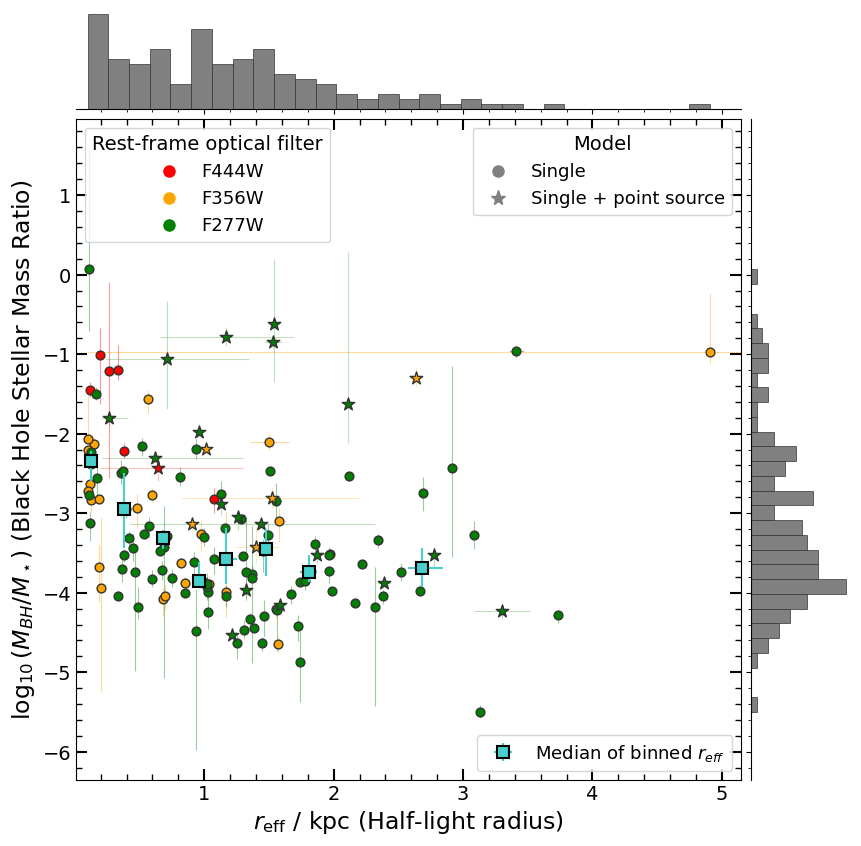

140
140
140


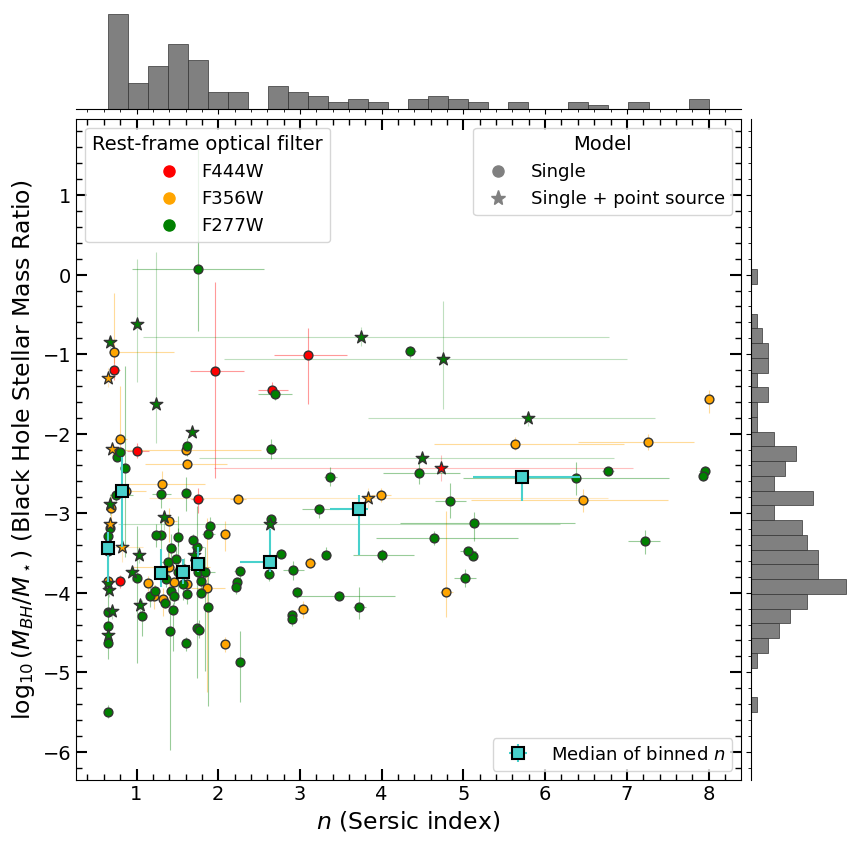

140
140
140


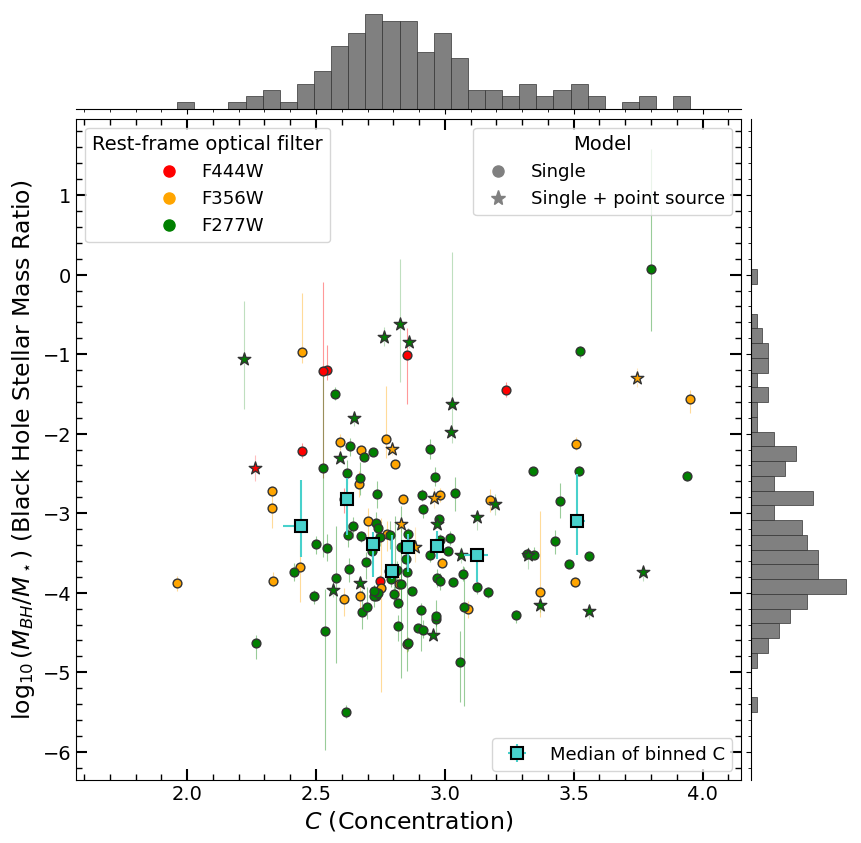

140
140
140


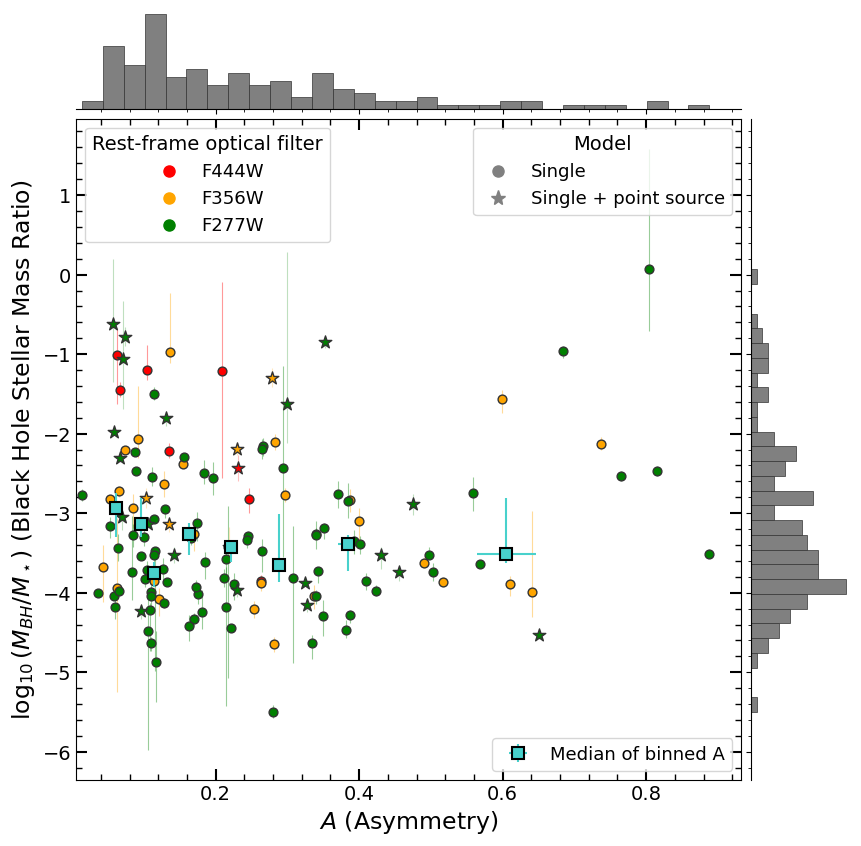

140
140
140


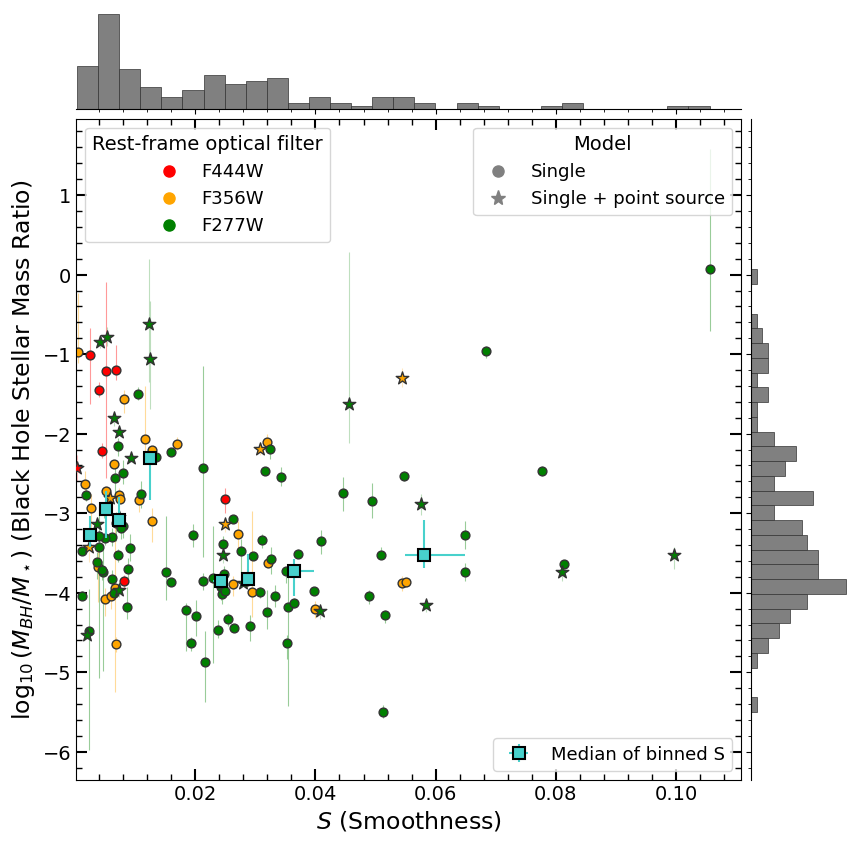

len of mask:  140


/tmp/ipykernel_2262780/103443253.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=13)


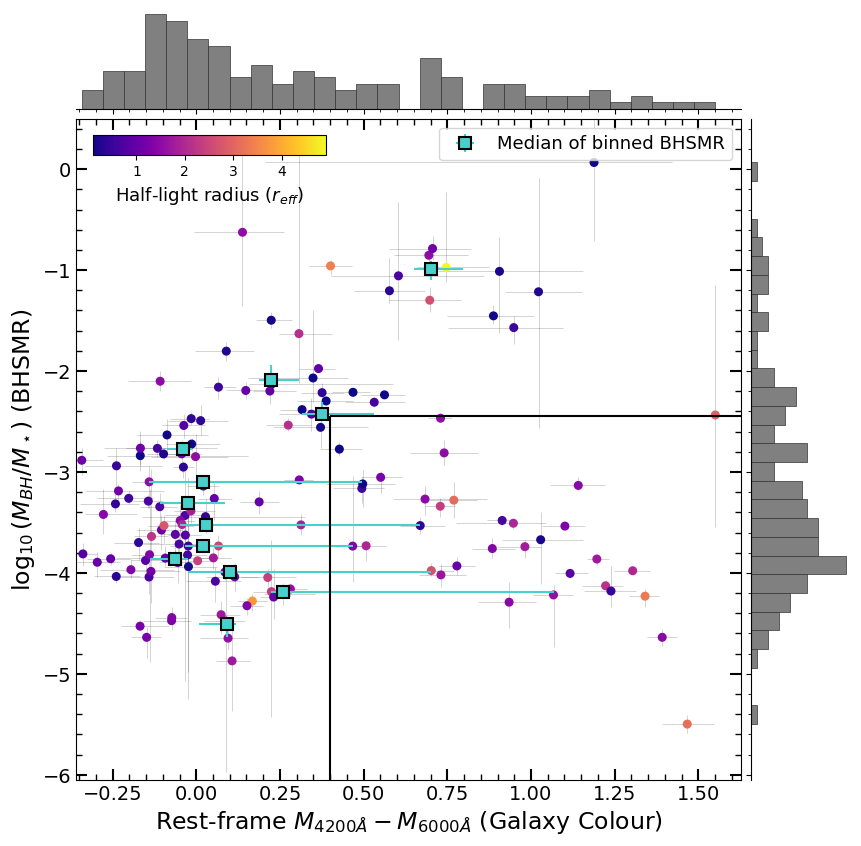

2.26–2.80: 4
2.80–3.60: 3
3.60–3.96: 4
3.96–5.34: 3
5.34–6.76: 3


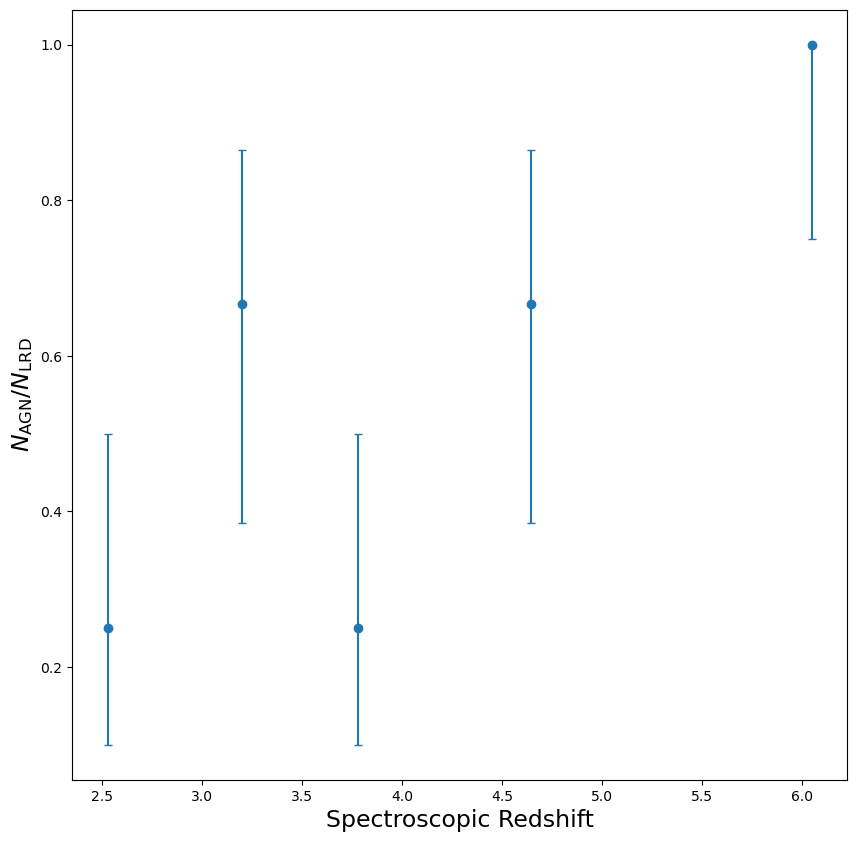

Subset ids:  [  3514   5201   6730   6944   8231   9026  11701  11723  19435  19573
  19882  20371  22942  23392  38176  39860  40623  40808  44883  48965
  57337  59715  61573  73098  83894  86583  98300 140605 146132 208439
 211293 216681]
len of mask:  140


/tmp/ipykernel_2262780/3012080980.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=13)


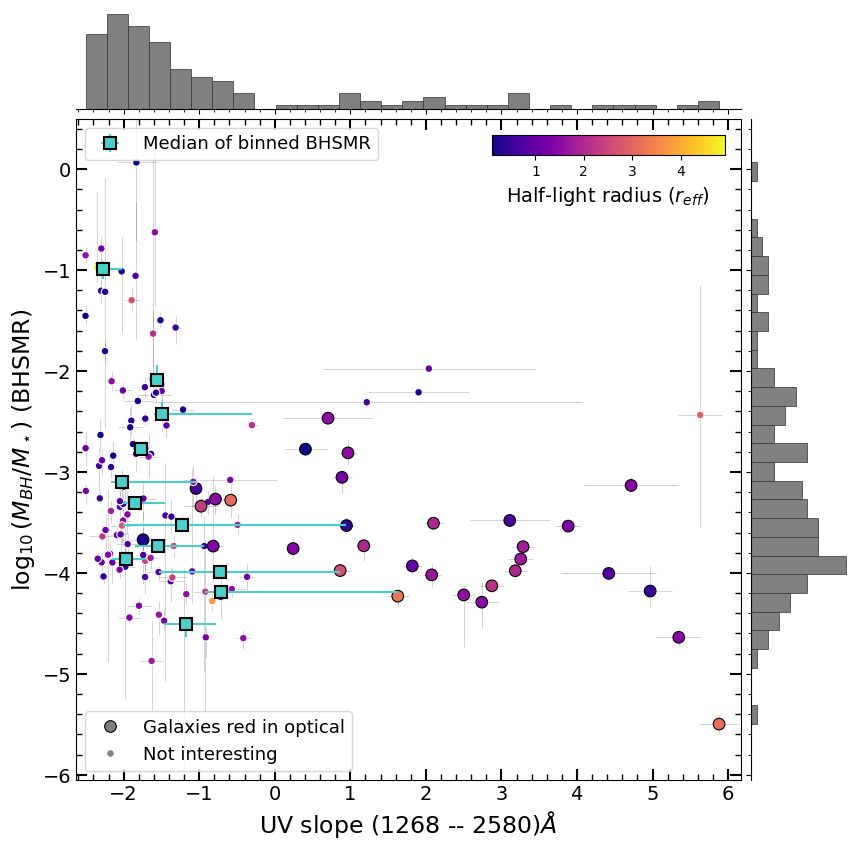

/tmp/ipykernel_2262780/278688035.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


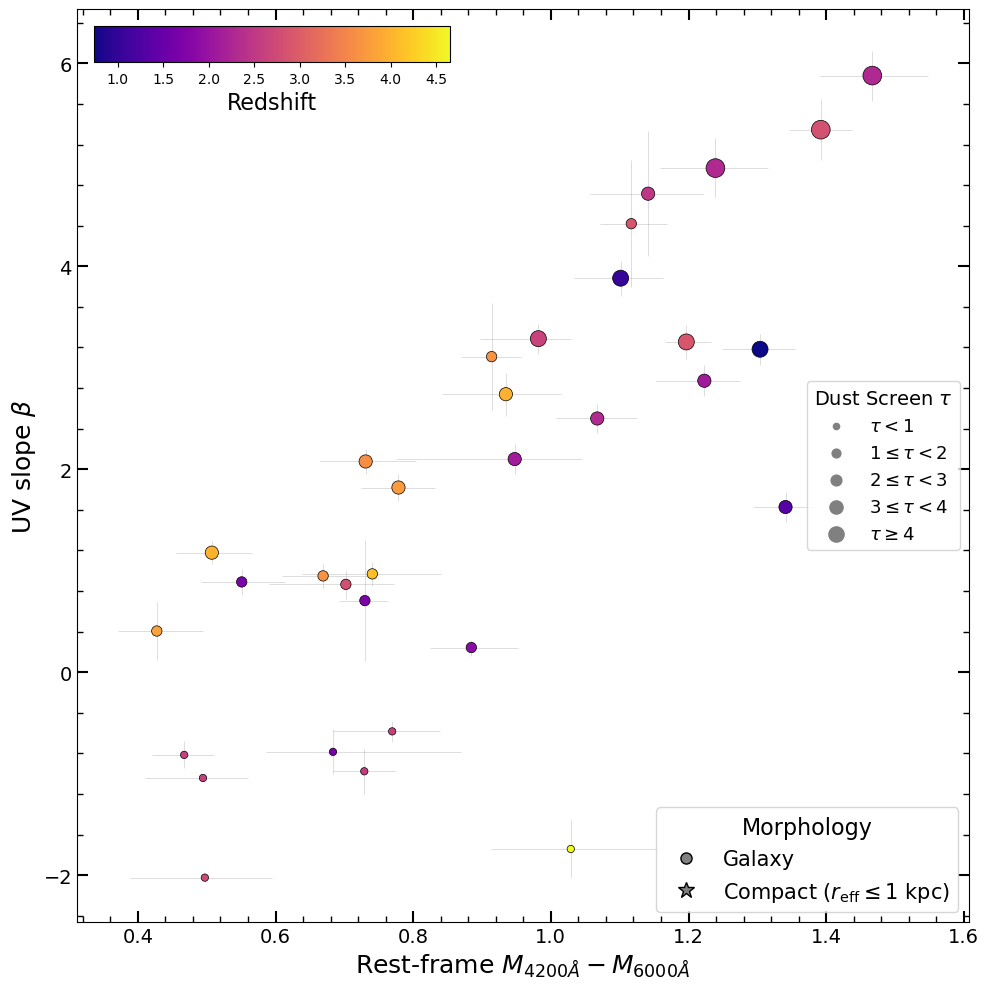

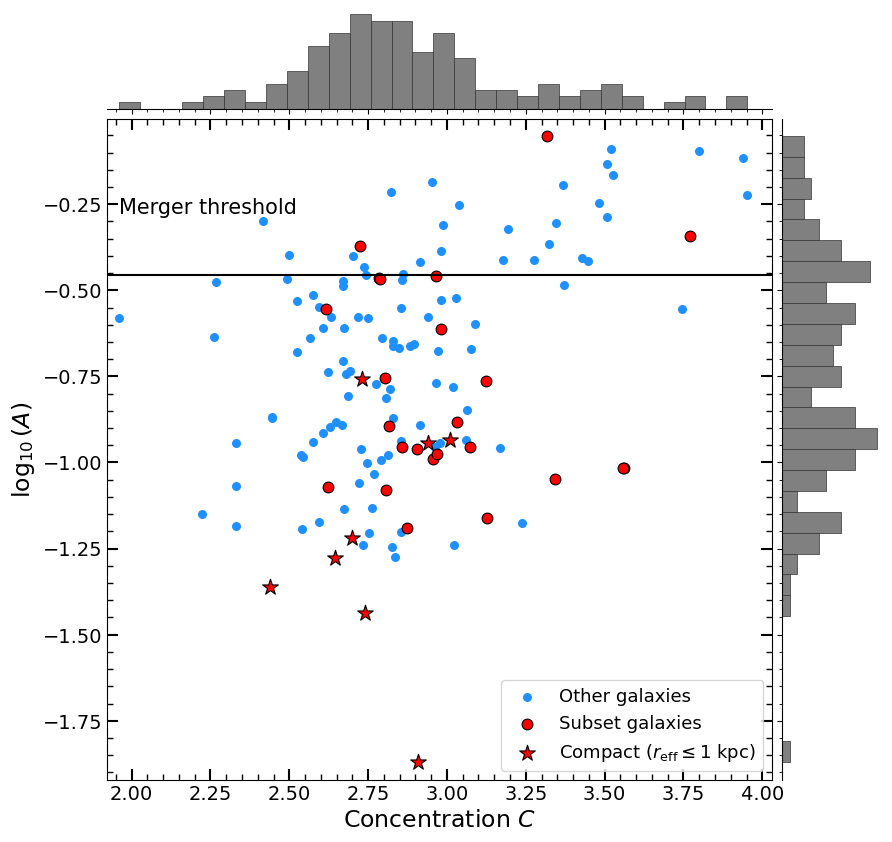

A vs C mergers of interest:  [ 48965  73098 140605]


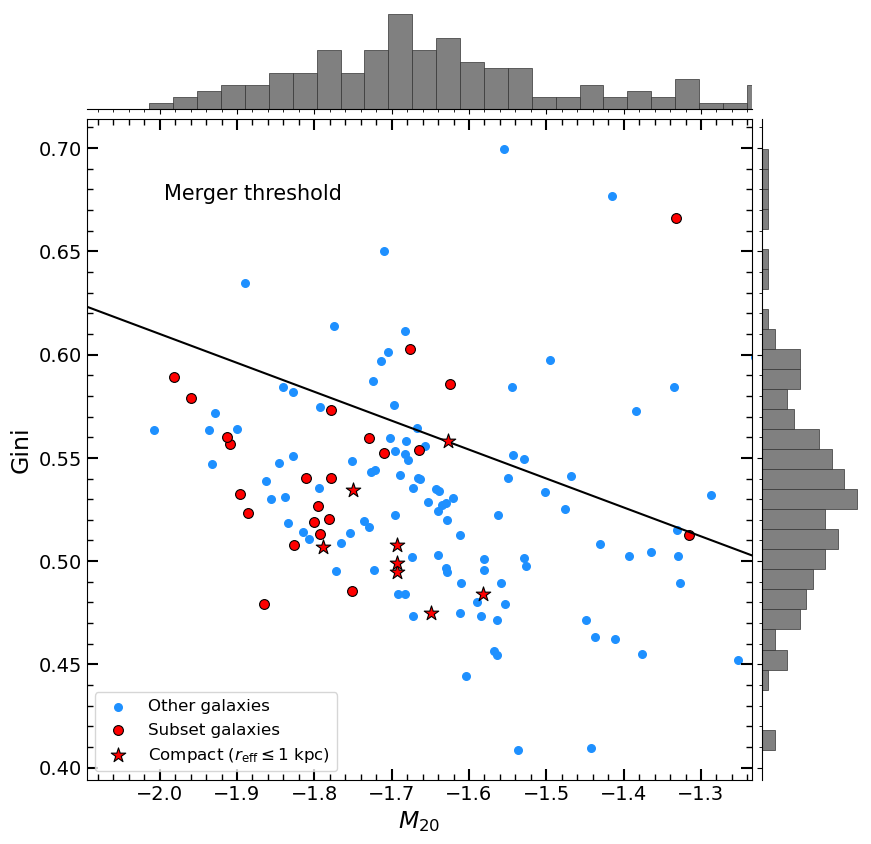

G vs M20 mergers of interest:  [11723 19882 38176 40808]


100%|██████████| 2000/2000 [00:03<00:00, 552.26it/s]



For plot below: 
Reduced chi squared = 9.73e+04
Intrinsic scatter from fit = 0.911
NMAD of normalised residuals = 1.121


<IPython.core.display.Math object>

<IPython.core.display.Math object>

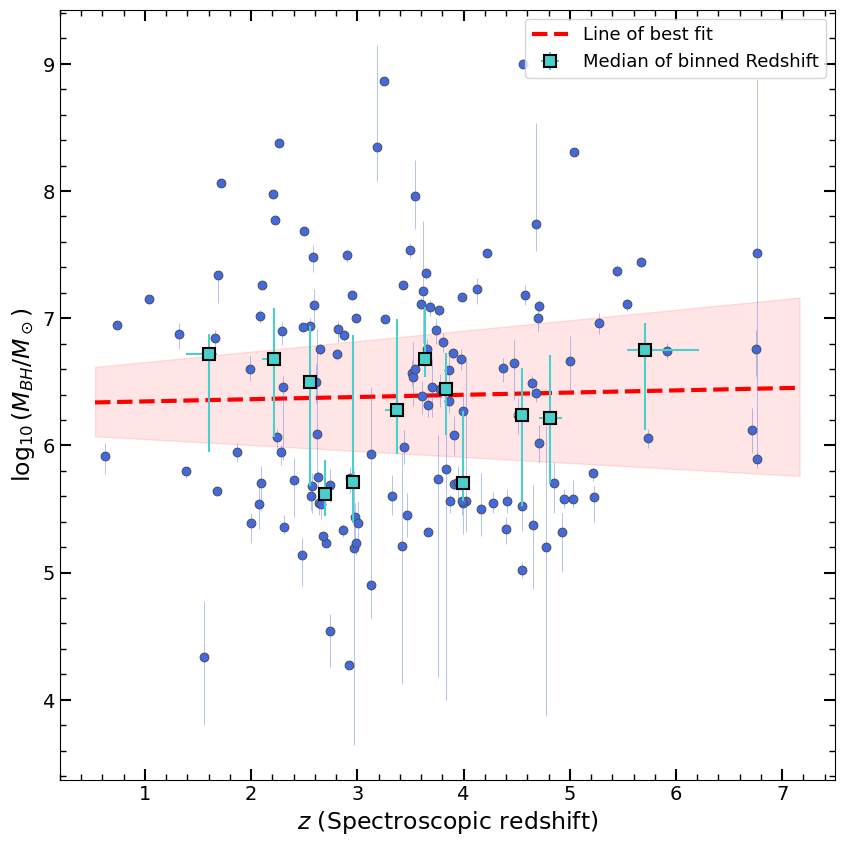

100%|██████████| 2000/2000 [00:03<00:00, 569.14it/s]



For plot below: 
Reduced chi squared = 320
Intrinsic scatter from fit = 0.815
NMAD of normalised residuals = 0.984


<IPython.core.display.Math object>

<IPython.core.display.Math object>

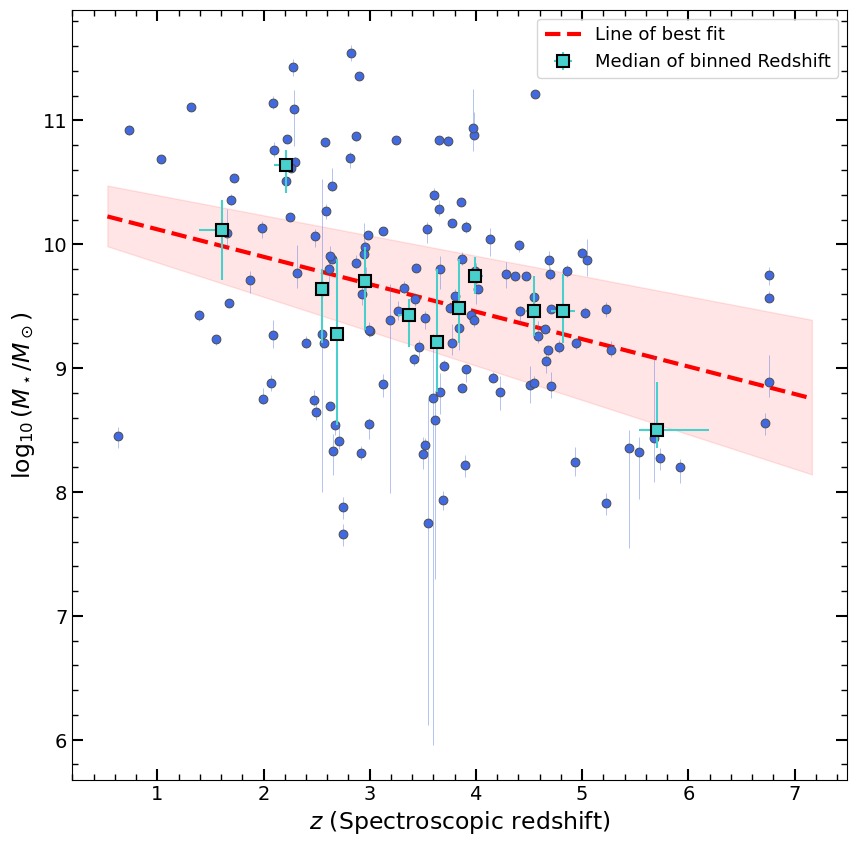

100%|██████████| 2000/2000 [00:03<00:00, 574.47it/s]



For plot below: 
Reduced chi squared = 142
Intrinsic scatter from fit = 0.909
NMAD of normalised residuals = 0.970


<IPython.core.display.Math object>

<IPython.core.display.Math object>

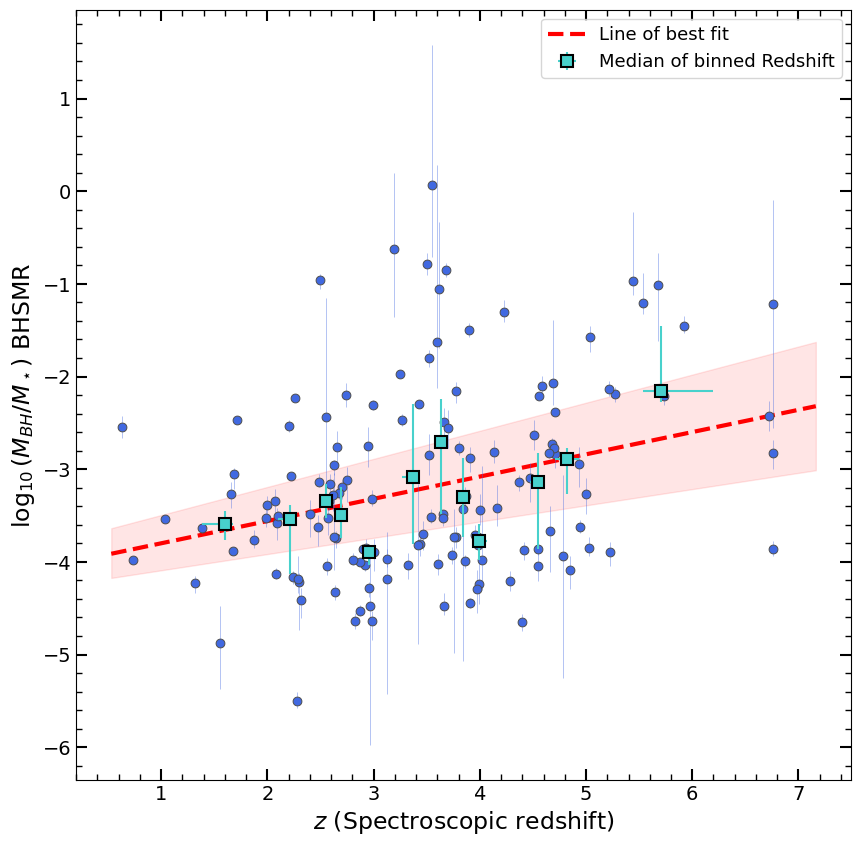

100%|██████████| 2000/2000 [00:03<00:00, 578.03it/s]



For plot below: 
Reduced chi squared = 746
Intrinsic scatter from fit = 0.242
NMAD of normalised residuals = 0.737


<IPython.core.display.Math object>

<IPython.core.display.Math object>

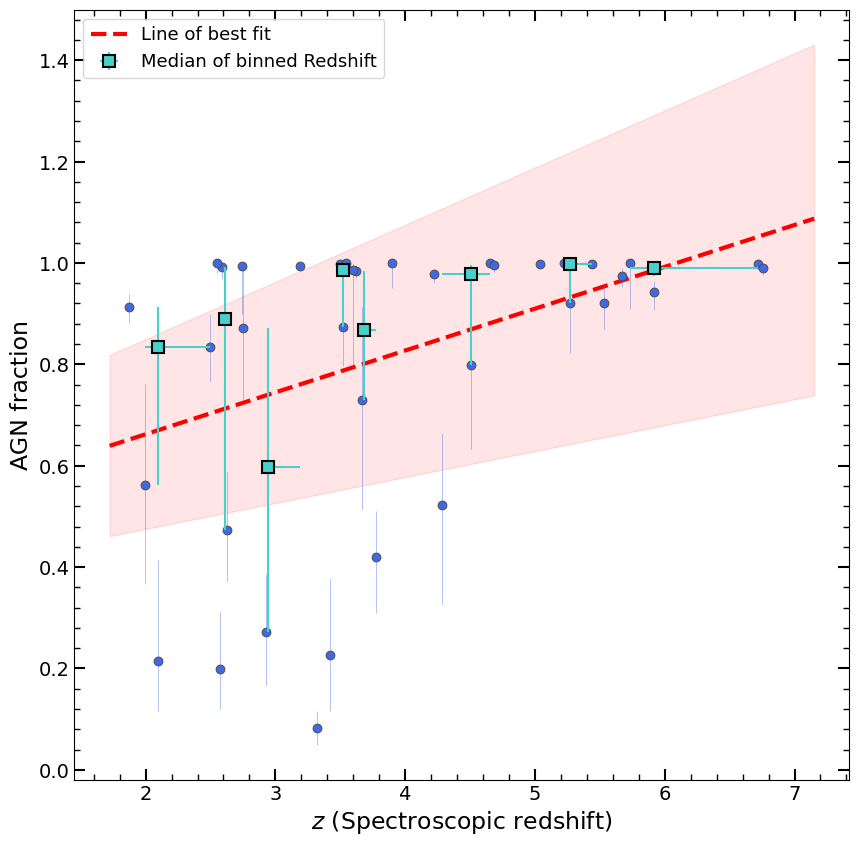

  0%|          | 0/2000 [00:00<?, ?it/s]/nvme/scratch/software/anaconda3/envs/lewi_galfind/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:01<00:00, 1879.24it/s]



For plot below: 
Reduced chi squared = 9.09e+03
Intrinsic scatter from fit = 0.733
NMAD of normalised residuals = 0.904


<IPython.core.display.Math object>

<IPython.core.display.Math object>

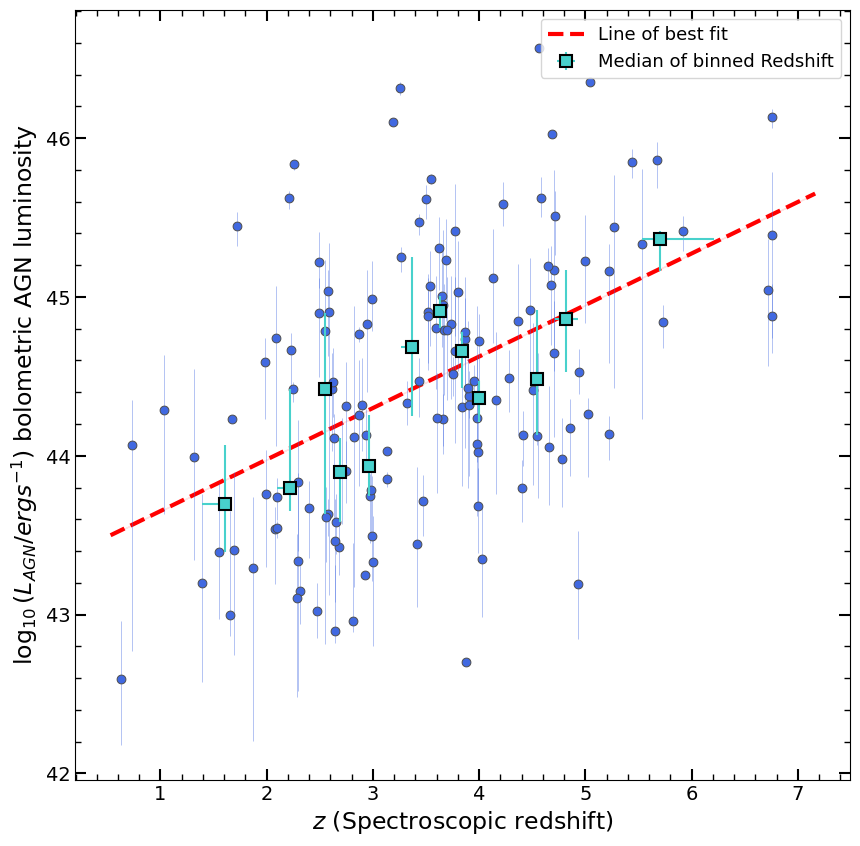

/tmp/ipykernel_2262780/252826926.py:7: RuntimeWarning: divide by zero encountered in log10
  y_lower_err = np.log10(y) - np.log10(np.abs(y - y_lower_err)) #log10
100%|██████████| 2000/2000 [00:03<00:00, 567.28it/s]



For plot below: 
Reduced chi squared = 169
Intrinsic scatter from fit = 0.647
NMAD of normalised residuals = 0.905


<IPython.core.display.Math object>

<IPython.core.display.Math object>

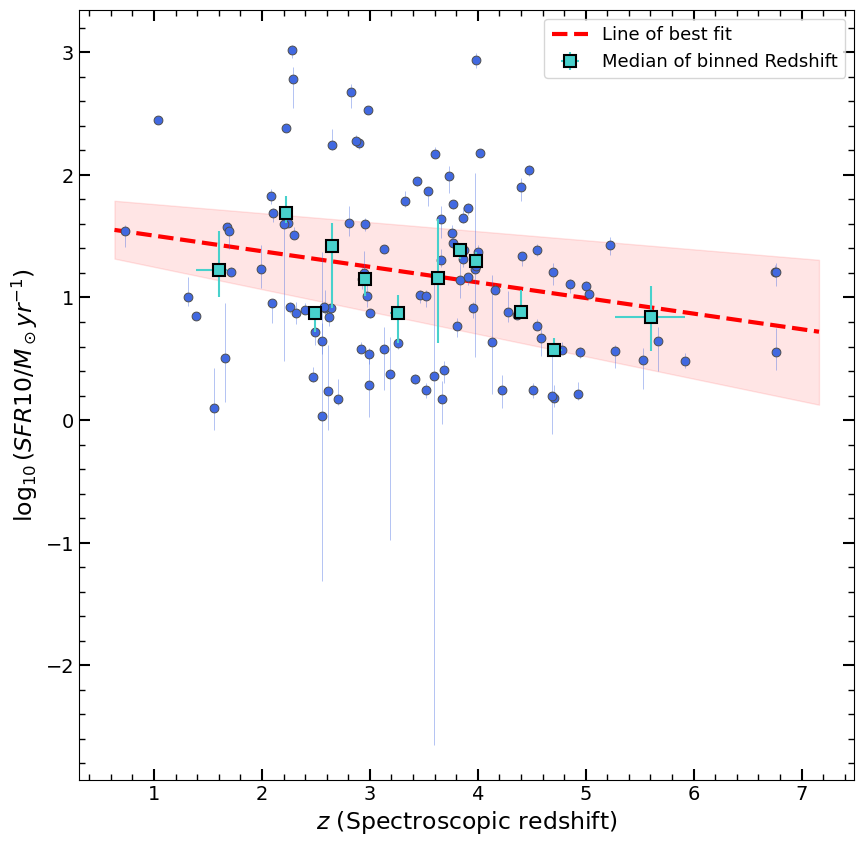

100%|██████████| 2000/2000 [00:03<00:00, 583.28it/s]



For plot below: 
Reduced chi squared = 176
Intrinsic scatter from fit = 0.644
NMAD of normalised residuals = 0.949


<IPython.core.display.Math object>

<IPython.core.display.Math object>

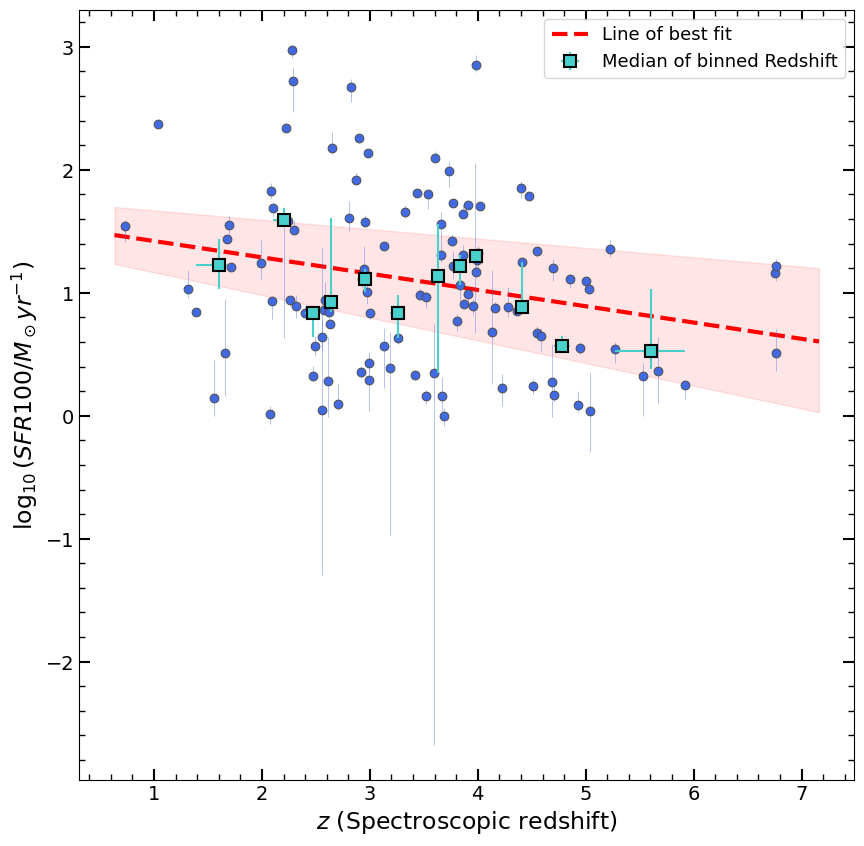

100%|██████████| 2000/2000 [00:03<00:00, 554.65it/s]



For plot below: 
Reduced chi squared = 102
Intrinsic scatter from fit = 0.616
NMAD of normalised residuals = 0.890


<IPython.core.display.Math object>

<IPython.core.display.Math object>

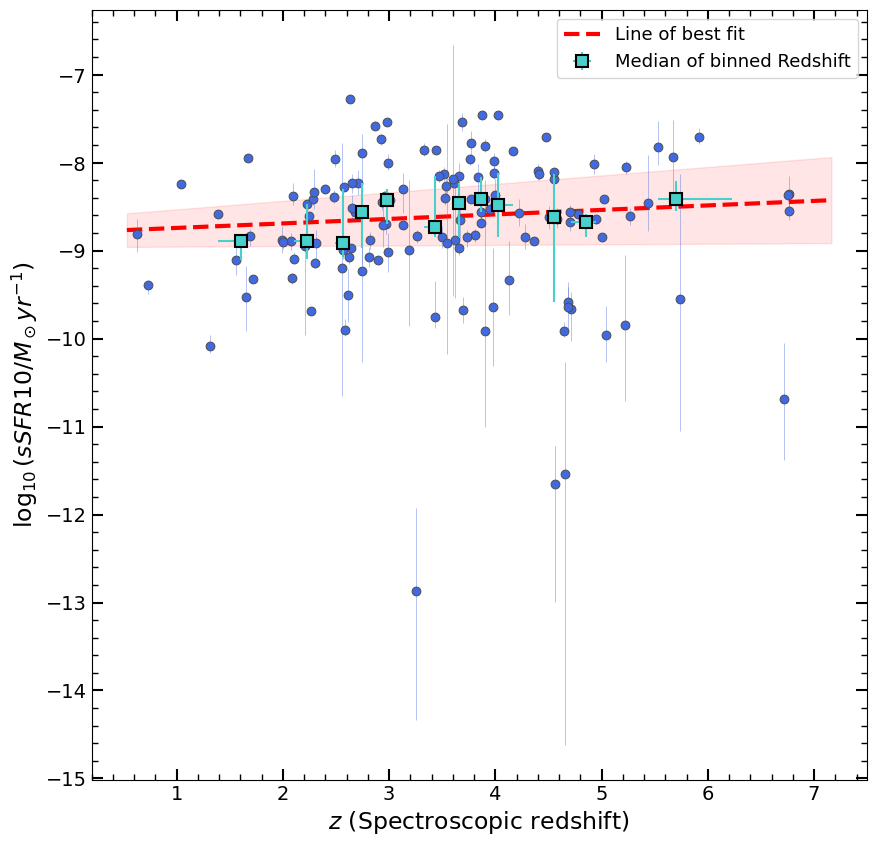

100%|██████████| 2000/2000 [00:03<00:00, 566.88it/s]



For plot below: 
Reduced chi squared = 59.5
Intrinsic scatter from fit = 0.514
NMAD of normalised residuals = 0.958


<IPython.core.display.Math object>

<IPython.core.display.Math object>

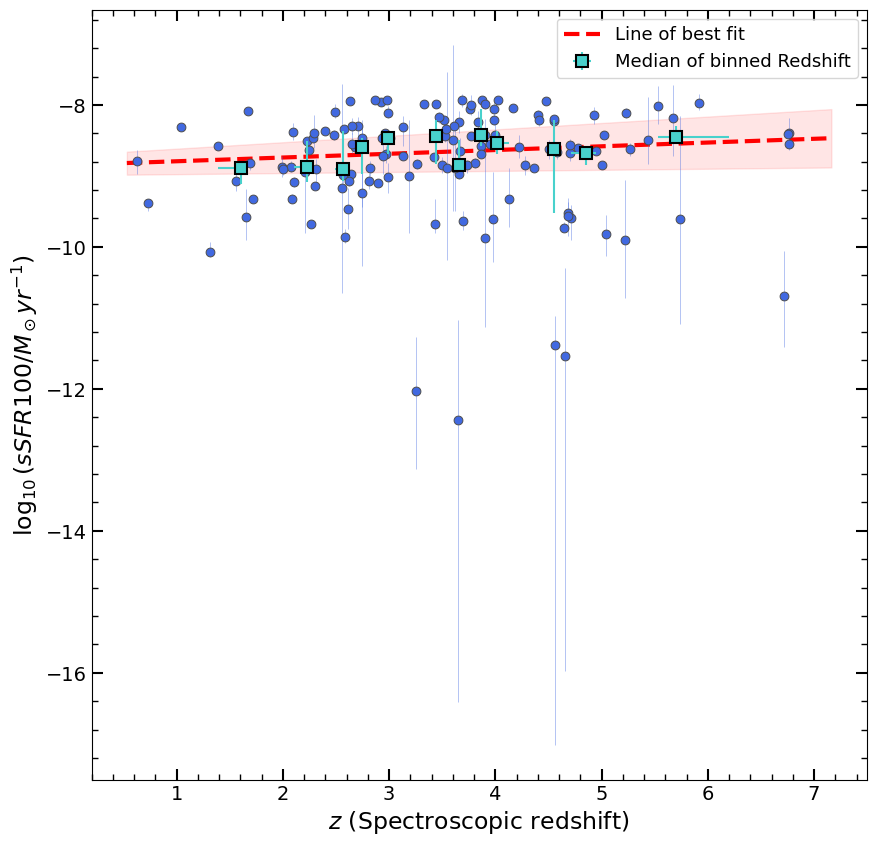

100%|██████████| 2000/2000 [00:03<00:00, 527.36it/s]



For plot below: 
Reduced chi squared = 8.6e+06
Intrinsic scatter from fit = 0.727
NMAD of normalised residuals = 0.940


<IPython.core.display.Math object>

<IPython.core.display.Math object>

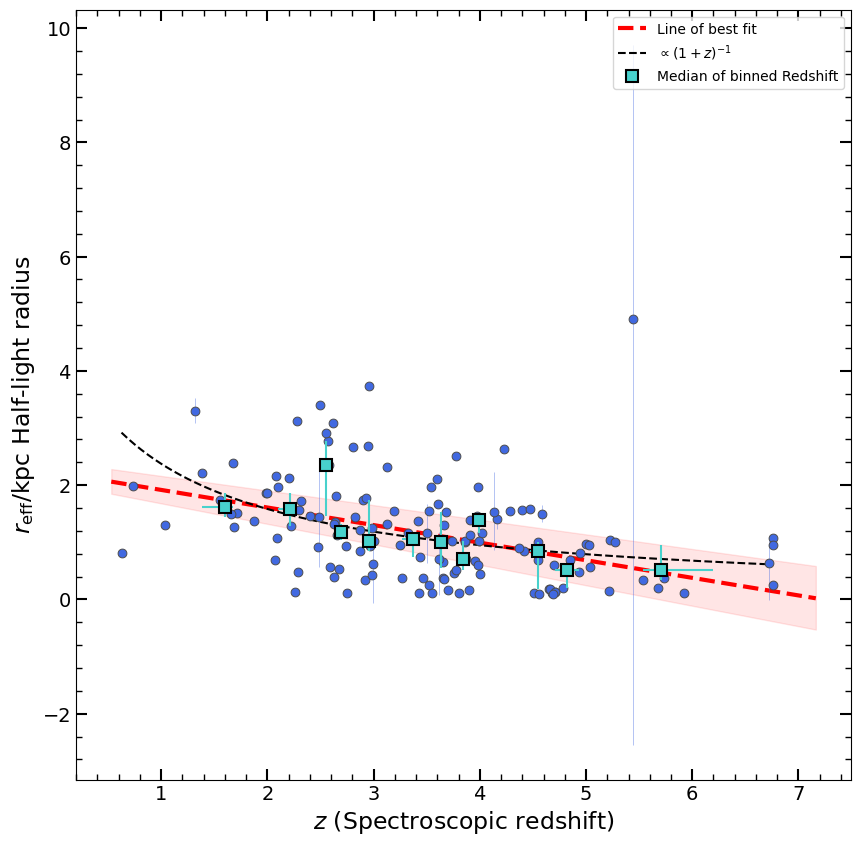

100%|██████████| 2000/2000 [00:03<00:00, 570.69it/s]



For plot below: 
Reduced chi squared = 1.66e+08
Intrinsic scatter from fit = 1.679
NMAD of normalised residuals = 0.695


<IPython.core.display.Math object>

<IPython.core.display.Math object>

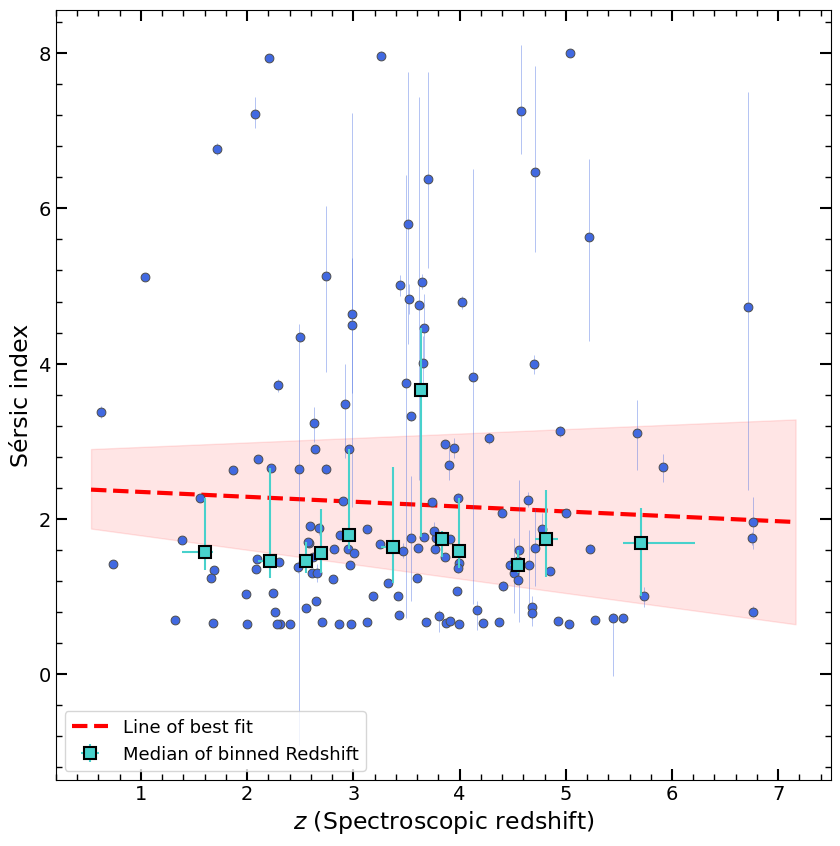

In [1029]:
if __name__ == "__main__":
    
    SED_tab = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits")

    # time_evolution_SED_data(SED_tab)

    morphology_tab = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/csv_tables/All_morphology_table.csv")

    morphology_and_galaxy_table = join(
                SED_tab,
                morphology_tab,
                keys=["SURVEY_ID", "REDSHIFT"]
    )
    table_path = os.path.join("/nvme/scratch/work/alberttg/Summer_project/Important_tables", "morphology_and_galaxy_table.csv")
    morphology_and_galaxy_table.write(table_path, format="csv", overwrite=True)

    print("For BIC filtered table: ")

    bhsmr_vs_r_eff(morphology_and_galaxy_table)

    bhsmr_vs_n(morphology_and_galaxy_table)

    bhsmr_vs_C(morphology_and_galaxy_table)

    bhsmr_vs_A(morphology_and_galaxy_table)

    bhsmr_vs_S(morphology_and_galaxy_table)

    interesting_galaxy_ids = plot_galaxy_colours(morphology_and_galaxy_table)
    print("Subset ids: ", interesting_galaxy_ids)

    bhsmr_vs_uv_slope(morphology_and_galaxy_table, interesting_galaxy_ids)

    uv_slope_vs_colour(morphology_and_galaxy_table, interesting_galaxy_ids)

    merger_ids_subset_A_C = log_A_vs_C(morphology_and_galaxy_table, interesting_galaxy_ids)
    print("A vs C mergers of interest: ", merger_ids_subset_A_C)

    merger_ids_subset_G_M = gini_vs_M20(morphology_and_galaxy_table, interesting_galaxy_ids)
    print("G vs M20 mergers of interest: ", merger_ids_subset_G_M)

    time_evolution_SED_data(morphology_and_galaxy_table)

    time_evolution_morphology(morphology_and_galaxy_table)
    """
    #--------------------------------------------------------------------------------------------------------------
    single_morph_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_3p0as/Single_sersic_fits_table.fits")

    single_morph_galaxy_table = join(
            SED_tab,
            single_morph_table,
            keys=["SURVEY_ID", "SURVEY", "REDSHIFT"]
    )

    print("For single sersic fits only: ")

    # bhm_vs_morph(single_morph_galaxy_table) needs a mask for 0 errs

    stacked_bhsmr_vs_morph(single_morph_galaxy_table)

    individual_plots_bhsmr_vs_n(single_morph_galaxy_table)

    
    #--------------------------------------------------------------------------------------------------------------

    PS_single_morph_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_0p96as/PS_single_sersic_NEW_fits_table.fits")

    PS_single_morph_galaxy_table = join(
                SED_tab,
                PS_single_morph_table,
                keys=["SURVEY_ID", "SURVEY", "REDSHIFT"]
        )

    print("For single+PS fits only: ")

    plot_bhsmr_vs_flux(PS_single_morph_galaxy_table)

    stacked_bhsmr_vs_morph(PS_single_morph_galaxy_table)

    individual_plots_bhsmr_vs_r_eff(PS_single_morph_galaxy_table)

    individual_plots_bhsmr_vs_n(PS_single_morph_galaxy_table)
    """
    #---------------------------------------------------------------------------------------------------------------------------------------
    